<a href="https://colab.research.google.com/github/JeraldinneReina/Aplicando-Python/blob/main/Exploraci%C3%B3n_y_Preparaci%C3%B3n_de_Datos_para_la_Predicci%C3%B3n_de_Precios_de_Apartamentos_en_Bogot%C3%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundación Universitaria Konrad Lorenz

Taller EDA: Exploración y Preparación de Datos para la Predicción de
Precios de Apartamentos en Bogotá

Presentado: Lina Higuera - Jeraldinne Reina - Daniela Romero

Facultad: Maestría & Especialización en Analítica Estratégica de Datos

Asignatura: Machine Learning Probabilístico

Fecha: 15/03/2026

In [ ]:
# =============================================================================
# LIBRERÍAS NECESARIAS
# =============================================================================

# Tratamiento de datos
# -----------------------------------------------------------------------------
import numpy as np
import pandas as pd
from tabulate import tabulate
from scipy import stats

# Gráficos
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib import style
import matplotlib.ticker as ticker
import seaborn as sns
import statsmodels.api as sm
import plotly.express as px

# Configuración matplotlib
# -----------------------------------------------------------------------------
plt.rcParams['image.cmap'] = "bwr"
plt.rcParams['savefig.bbox'] = "tight"
style.use('ggplot') or plt.style.use('ggplot')

# Configuración warnings
# -----------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')



In [ ]:
import os
print("/content/drive/MyDrive/apartamentos_bogota.xlsx:", os.getcwd())

/content/drive/MyDrive/apartamentos_bogota.xlsx: /content


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# ===================================================== Lectura Dataset ==========================================================

#DANIELA
#datos = pd.read_excel("/content/drive/MyDrive/apartamentos_bogota.xlsx")

#LINA
#datos = pd.read_excel("/content/drive/MyDrive/MACHINE LEARNING/EDA/TALLER/apartamentos_bogota.xlsx")

#JERALDINNE
datos = pd.read_excel("/content/drive/MyDrive/Bases_de_Datos/apartamentos_bogota.xlsx")



# Conjunto de datos Análisis Completo del Mercado Inmobiliario de Bogotá - Análisis de Precios de Viviendas

##Descripción del dataset

El Conjunto de datos `Apartamentos en Bogotá` es una base con información detallada sobre la oferta inmobiliaria de 43.013 apartamentos y casas en la ciudad de Bogotá del año 2024.

## Variables del Dataset
## 1. Información básica
*  `Código`: Identificador único del apartamento
*   `tipo_propiedad`: Tipo de inmueble
*   `tipo_operacion`: Modalidad comercial
*   `precio_venta`: Precio de venta en COP
*   `precio_arriendo`: Precio de arriendo mensual en COP
*   `area`: Área en metros cuadrados
*   `habitaciones`: Número de habitaciones
*   `banos`: Número de baños
*   `administracion`: Cuota de administración mensual
*   `parqueaderos`: Número de parqueaderos

##2. Ubicación y Contexto


*   `sector`: Zona/Sector de ubicación
*   `localidad`: Localidad de Bogotá
*   `barrio`: Barrio específico
*   `estrato`: Estrato socioeconómico (1-6)
*  `longitud`: Coordenada geográfica
*   `latitud`: Coordenada geográfica (1-6)
*   `coords_modified`: Indica si las coordenadas fueron ajustadas

##3. Características del Inmueble
*   `antiguedad`: Años de construcción
*   `estado`: Estado del inmueble
*   `piso`: Número de piso
*   `closets`: Número de closets


##4. Amenidades y servicios
*   `jacuzzi`: Disponibilidad de jacuzzi
*   `piscina`: Acceso a piscina
*   `salon_comunal`: comunal disponible
*   `terraza`: Terraza privada
*   `vigilancia`: Vigilancia privada 24/7
*   `chimenea`: Chimenea disponible
*   `permite_mascotas`: Política de mascotas
*   `gimnasio`: Gimnasio en el edificio
*   `ascensor`: Ascensor disponible
*   `conjunto_cerrado`: Ubicado en conjunto cerrado


##5. Análisis de Proximidad

*   `estacion_tm_cercana`: Estación de TransMilenio más cercana
*   `distancia_estacion_tm_m`: Distancia en metros a TransMilenio
*   `is_cerca_estacion_tm`: Dentro de 500m de TransMilenio
*   `parque_cercano`: Parque más cercano al apartamento
*   `distancia_parque_m`: Distancia en metros al parque
*   `is_cerca_parque`: Dentro de 500m de un parque
*   `centro_comercial_cercano`: Centro comercial más cercano
*   `distancia_centro_comercial_m`: Distancia en metros al centro comercial
*   `is_cerca_centro_comercial`: Dentro de 800m de un centro comercial

##6. Metadatos y Tracking

*   `website`: Fuente de los datos
*   `compañia`: Inmobiliaria responsable
*   `last_view`: Última verificación del scraper
*   `timeline`: Historial de precios
*   `url	String`: original del anuncio
*   `descripcion`: Descripción detallada
*   `datetime`: Timestamp de extracción

## Tipo de variables a evaluar


1.   Variables Numéricas Continuas: precio_venta, area, administracion, distancia_estacion_tm_m.
2.   Variables Numéricas Discretas:habitaciones, banos, parqueaderos
3.   Variables Categóricas nóminales: localidad, sector, antiguedad.
4.   Variables Categóricas ordinales: estrato
5.   Variables Booleanas: ascensor, piscina, is_cerca_parque
















In [ ]:
print(f"Total number of records in the DataFrame: {len(datos)}")

Total number of records in the DataFrame: 43013


#ENTENDIMIENTO DE LOS DATOS

In [ ]:
datos.head(10)
datos.tail(10)


,_id,codigo,tipo_propiedad,tipo_operacion,precio_venta,area,habitaciones,banos,administracion,parqueaderos,...,vigilancia,coords_modified,localidad,barrio,estacion_tm_cercana,distancia_estacion_tm_m,is_cerca_estacion_tm,parque_cercano,distancia_parque_m,is_cerca_parque
43003,{'$oid': '66d86ebfceda690e85512f5b'},4357929,APARTAMENTO,VENTA,4.980000e+08,84.00,3,2,379000,1,...,0,False,USAQUEN,CANAPRO,Portal Norte,975.62,0,PARQUE VECINAL URBANIZACIÓN CALLE 170 / ALAMEDA,108.84,1
43004,{'$oid': '66d86ebfceda690e85512f5c'},4518221,APARTAMENTO,VENTA,1.941300e+08,47.00,2,1,173999,0,...,0,False,KENNEDY,MORABIA II,Sevillana,1175.50,0,PARQUE VECINAL LA ALEJANDRA,232.86,1
43005,{'$oid': '66d86ebfceda690e85512f5d'},2494474,APARTAMENTO,VENTA,1.370000e+08,47.00,3,1,62000,0,...,0,False,BOSA,S.C. SAN BERNARDINO XXII,Portal Américas,4408.60,0,PARQUE VECINAL URBANIZACIÓN PORTAL DEL SOL,905.81,0
43006,{'$oid': '66d86ebfceda690e85512f5e'},4274786,APARTAMENTO,VENTA,1.210000e+08,35.00,2,1,76200,0,...,0,False,KENNEDY,LOS CONDOMINIOS DETIERRA BUENA I,Biblioteca Tintal,1776.06,0,PARQUE VECINAL PRIMAVERA,876.37,0
43007,{'$oid': '66d86ebfceda690e85512f5f'},4409301,APARTAMENTO,VENTA,1.300000e+08,37.00,2,1,77000,0,...,0,False,BOSA,S.C OSORIO DIEZ,Portal Américas,2004.86,0,PARQUE METROPOLITANO PORVENIR,301.87,1
43008,{'$oid': '66d86ebfceda690e85512f60'},4323513,APARTAMENTO,VENTA,1.900000e+08,49.00,3,2,204624,0,...,0,False,SUBA,URB. OVIEDO,Portal Suba,1712.71,0,PARQUE ZONAL CAMPO VERDE,198.03,1
43009,{'$oid': '66d86ebfceda690e85512f61'},4345085,APARTAMENTO,VENTA,3.220000e+08,66.00,3,2,277400,1,...,0,False,SUBA,LOS TEJARES DE SUBA (PREDIO),La Campiña,120.16,1,PARQUE ZONAL BELLAVISTA DINDALITO,631.25,0
43010,{'$oid': '66d86ebfceda690e85512f62'},MC5206960,APARTAMENTO,VENTA,3.300000e+08,90.00,3,2,112000,0,...,0,False,TEUSAQUILLO,LAS AMERICAS,AV. ElDorado,33.21,1,PARQUE METROPOLITANO EL RENACIMIENTO - PARQUE ...,1211.62,0
43011,{'$oid': '66d86ebfceda690e85512f63'},MC5203688,APARTAMENTO,VENTA,1.280000e+09,157.00,3,3,1050000,3,...,0,False,USAQUEN,S.C. SAN NORTE,Calle 127,3005.88,0,PARQUE METROPOLITANO EL COUNTRY,1269.56,0
43012,{'$oid': '66d86ebfceda690e85512f64'},MC4721977,APARTAMENTO,VENTA,4.980000e+08,84.34,3,2,287000,1,...,0,False,KENNEDY,HIPOTECHO OCCIDENTAL II,Marsella,1022.07,0,PARQUE ZONAL LA IGUALDAD,648.01,0


In [ ]:
datos.columns

Index(['_id', 'codigo', 'tipo_propiedad', 'tipo_operacion', 'precio_venta',
       'area', 'habitaciones', 'banos', 'administracion', 'parqueaderos',
       'sector', 'estrato', 'antiguedad', 'latitud', 'longitud', 'direccion',
       'descripcion', 'website', 'last_view', 'datetime', 'url', 'timeline',
       'estado', 'compañia', 'precio_arriendo', 'jacuzzi', 'piso', 'closets',
       'chimenea', 'permite_mascotas', 'gimnasio', 'ascensor',
       'conjunto_cerrado', 'piscina', 'salon_comunal', 'terraza', 'vigilancia',
       'coords_modified', 'localidad', 'barrio', 'estacion_tm_cercana',
       'distancia_estacion_tm_m', 'is_cerca_estacion_tm', 'parque_cercano',
       'distancia_parque_m', 'is_cerca_parque'],
      dtype='object')

In [ ]:
# Renombrar variables
datos.columns = ["id","codigo", "tipo_propiedad", "tipo_operacion", "precio_venta",
                 "area", "habitaciones","banyos", "administracion", "parqueaderos",
                 "sector", "estrato","antiguedad","latitud","longitud","direccion",
                 "descripcion", "website","ultima_vista","fecha_hora","url","cronologia",
                 "estado","compania","precio_arriendo", "jacuzzi","piso", "closets",
                 "chimenea","permite_mascotas","gimnasio","ascensor","conjunto_cerrado",
                 "piscina","salon_comunal","terraza","vigilancia", "coordenadas_modificadas",
                 "localidad", "barrio","estacion_tm_cercana","distancia_estacion_tm_m",
                 "esta_cerca_estacion_tm","parque_cercano","distancia_parque_m","esta_cerca_parque" ]

In [ ]:
datos.columns

Index(['id', 'codigo', 'tipo_propiedad', 'tipo_operacion', 'precio_venta',
       'area', 'habitaciones', 'banyos', 'administracion', 'parqueaderos',
       'sector', 'estrato', 'antiguedad', 'latitud', 'longitud', 'direccion',
       'descripcion', 'website', 'ultima_vista', 'fecha_hora', 'url',
       'cronologia', 'estado', 'compania', 'precio_arriendo', 'jacuzzi',
       'piso', 'closets', 'chimenea', 'permite_mascotas', 'gimnasio',
       'ascensor', 'conjunto_cerrado', 'piscina', 'salon_comunal', 'terraza',
       'vigilancia', 'coordenadas_modificadas', 'localidad', 'barrio',
       'estacion_tm_cercana', 'distancia_estacion_tm_m',
       'esta_cerca_estacion_tm', 'parque_cercano', 'distancia_parque_m',
       'esta_cerca_parque'],
      dtype='object')

In [ ]:
datos.head()

,id,codigo,tipo_propiedad,tipo_operacion,precio_venta,area,habitaciones,banyos,administracion,parqueaderos,...,vigilancia,coordenadas_modificadas,localidad,barrio,estacion_tm_cercana,distancia_estacion_tm_m,esta_cerca_estacion_tm,parque_cercano,distancia_parque_m,esta_cerca_parque
0,{'$oid': '66d86c7eceda690e85508760'},4133491,APARTAMENTO,VENTA,339000000.0,76.0,3,2,300000,1,...,0,False,SUBA,URB. PICADELLY,Toberin - Foundever,1142.45,0,PARQUE VECINAL DESARROLLO CANTALEJO URBANIZACI...,426.09,1
1,{'$oid': '66d86c7eceda690e85508761'},3889852,APARTAMENTO,VENTA,223000000.0,63.0,3,2,{'$numberDouble': 'NaN'},0,...,0,False,USAQUEN,BARRANCAS PERLAS DEL NORTE,Mazurén,2384.89,0,PARQUE ZONAL ALTA BLANCA,472.47,1
2,{'$oid': '66d86c7eceda690e85508762'},4386770,APARTAMENTO,VENTA,440898168.0,54.0,3,2,305000,0,...,0,False,LOS MARTIRES,SAN VICTORINO,De La Sabana,232.22,1,PARQUE METROPOLITANO TERCER MILENIO,961.29,0
3,{'$oid': '66d86c7eceda690e85508763'},4210060,APARTAMENTO,VENTA,158000000.0,43.0,2,2,106600,0,...,0,False,SUBA,LA ESTRELLA II,Portal Suba,2275.08,0,PARQUE ZONAL LA GAITANA,539.98,0
4,{'$oid': '66d86c7eceda690e85508764'},4063762,APARTAMENTO,VENTA,222800000.0,48.0,3,2,151000,0,...,0,False,USAQUEN,HORIZONTES USAQUEN,Terminal,2099.16,0,PARQUE VECINAL DESARROLLO VERBENAL I,1661.14,0


In [ ]:
datos['closets'].head().unique()

<IntegerArray>
[<NA>]
Length: 1, dtype: Int64




# Tipo de columnas





In [ ]:
#Información detallada por cad columna (cantidad de nulos y de tipo de dato)
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43013 entries, 0 to 43012
Data columns (total 46 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       43013 non-null  object        
 1   codigo                   43013 non-null  object        
 2   tipo_propiedad           43013 non-null  object        
 3   tipo_operacion           43013 non-null  object        
 4   precio_venta             27584 non-null  float64       
 5   area                     43013 non-null  float64       
 6   habitaciones             43013 non-null  object        
 7   banyos                   43013 non-null  object        
 8   administracion           43013 non-null  object        
 9   parqueaderos             43013 non-null  object        
 10  sector                   43013 non-null  object        
 11  estrato                  43013 non-null  object        
 12  antiguedad               43013 n

In [ ]:
# 1. Convertir numéricas que están como object
cols_a_numericas = ['habitaciones', 'banyos', 'administracion']

for col in cols_a_numericas:
    # pd.to_numeric con errors='coerce' convierte lo no numérico en NaN
    datos[col] = pd.to_numeric(datos[col], errors='coerce')

# 2. Convertir columnas object a entero
cols_a_entero = ['parqueaderos', 'estrato', 'piso',  'closets']

for col in cols_a_entero:
    # Primero convertir a numérico para manejar strings como "{'$numberDouble': 'NaN'}"
    datos[col] = pd.to_numeric(datos[col], errors='coerce')
    # Convertir a Int64 (entero nullable que soporta NaN)
    datos[col] = datos[col].round(0).astype('Int64')

# 3. Convertir amenidades a booleanas (asumiendo que vienen como 'Si'/'No' o '1'/'0')
# Ajusta el diccionario según lo que veas en tu df.head()
mapeo_bool = {'Si': True, 'No': False, '1': True, '0': False, True: True, False: False}

cols_amenidades = ['jacuzzi', 'chimenea', 'permite_mascotas', 'gimnasio',
                   'ascensor', 'conjunto_cerrado', 'piscina', 'salon_comunal',
                   'terraza', 'vigilancia','esta_cerca_estacion_tm', 'esta_cerca_parque'] # Corrected: Removed trailing space

for col in cols_amenidades:
    datos[col] = datos[col].map(mapeo_bool).fillna(False).astype(bool)

# 4. Convertir a categorías
datos['localidad'] = datos['localidad'].astype('category')
datos['antiguedad'] = datos['antiguedad'].astype('category')

# Verificamos los cambios
print(datos[cols_a_numericas + cols_a_entero + cols_amenidades].dtypes)


habitaciones              float64
banyos                    float64
administracion            float64
parqueaderos                Int64
estrato                     Int64
piso                        Int64
closets                     Int64
jacuzzi                      bool
chimenea                     bool
permite_mascotas             bool
gimnasio                     bool
ascensor                     bool
conjunto_cerrado             bool
piscina                      bool
salon_comunal                bool
terraza                      bool
vigilancia                   bool
esta_cerca_estacion_tm       bool
esta_cerca_parque            bool
dtype: object


#Renombrar registros mal categorizados
1. Recategorización en tipo_operación: Se identificaron 27.584 registros con valor precio_venta, y 27.498 registros entre venta, y venta y arriendo, una diferencia de 86 registros que estan marcados como solo arriendo.

2. Se realiza imputación de tipo de operación aquellos registros que  salen como venta y arriendo, por venta, ya que tan solo representan el 0.53% esta categoría, y se toma como solo venta.

In [ ]:
columna_str = datos['tipo_operacion'].apply(lambda x: str(x) if isinstance(x, (dict, list)) else x)
valores_unicos = columna_str.unique()
total_unicos = len(valores_unicos)

print(f"Valores únicos de la columna 'tipo_operacion' ({total_unicos} en total):")
for valor in sorted(valores_unicos, key=lambda x: (x is None, str(x))):
    print(f"   - {valor}")

Valores únicos de la columna 'tipo_operacion' (3 en total):
   - ARRIENDO
   - VENTA
   - VENTA Y ARRIENDO


In [ ]:
conteo_porcentaje = pd.DataFrame({
    'Conteo': datos['tipo_operacion'].value_counts(),
    'Porcentaje': (datos['tipo_operacion'].value_counts(normalize=True) * 100).round(2)
})
print("Distribución de 'tipo_operacion':")
display(conteo_porcentaje)

Distribución de 'tipo_operacion':


,Conteo,Porcentaje
tipo_operacion,,
VENTA,27270,63.40
ARRIENDO,15515,36.07
VENTA Y ARRIENDO,228,0.53


In [ ]:
# Identificar registros con precio_venta pero categorizados como ARRIENDO
registros_a_corregir = datos[(datos['tipo_operacion'] == 'ARRIENDO') & (datos['precio_venta'].notna())]

print(f"Número de registros 'ARRIENDO' con precio_venta: {len(registros_a_corregir)}")

# Cambiar 'tipo_operacion' a 'VENTA' para estos registros
datos.loc[registros_a_corregir.index, 'tipo_operacion'] = 'VENTA'

# Mostrar la distribución actualizada de 'tipo_operacion'
conteo_porcentaje_despues_correccion = pd.DataFrame({
    'Conteo': datos['tipo_operacion'].value_counts(),
    'Porcentaje': (datos['tipo_operacion'].value_counts(normalize=True) * 100).round(2)
})
print("\nDistribución de 'tipo_operacion' después de corregir los 86 registros:")
display(conteo_porcentaje_despues_correccion)

Número de registros 'ARRIENDO' con precio_venta: 86

Distribución de 'tipo_operacion' después de corregir los 86 registros:


,Conteo,Porcentaje
tipo_operacion,,
VENTA,27356,63.60
ARRIENDO,15429,35.87
VENTA Y ARRIENDO,228,0.53


In [ ]:
# Reemplazar 'VENTA Y ARRIENDO' por 'VENTA' en la columna 'tipo_operacion'
datos.loc[datos['tipo_operacion'] == 'VENTA Y ARRIENDO', 'tipo_operacion'] = 'VENTA'

# Mostrar la distribución actualizada
conteo_porcentaje_actualizado = pd.DataFrame({
    'Conteo': datos['tipo_operacion'].value_counts(),
    'Porcentaje': (datos['tipo_operacion'].value_counts(normalize=True) * 100).round(2)
})
print("Distribución de 'tipo_operacion' después de la unificación:")
display(conteo_porcentaje_actualizado)

Distribución de 'tipo_operacion' después de la unificación:


,Conteo,Porcentaje
tipo_operacion,,
VENTA,27584,64.13
ARRIENDO,15429,35.87


#Filtro Tipo_operación con el fin de solo analizar la información de Venta.

In [ ]:
# Filtrar por tipo_operación = 'VENTA'
datos_filtrado_venta = datos[datos['tipo_operacion'] == 'VENTA']

# Verificar resultado
print(f" Total registros originales : {len(datos)}")
print(f" Registros de VENTA      : {len(datos_filtrado_venta)}")
print(f"\n📋 Primeros registros filtrados:")
print(datos_filtrado_venta.head())

 Total registros originales : 43013
 Registros de VENTA      : 27584

📋 Primeros registros filtrados:
                                     id   codigo tipo_propiedad  \
0  {'$oid': '66d86c7eceda690e85508760'}  4133491    APARTAMENTO   
1  {'$oid': '66d86c7eceda690e85508761'}  3889852    APARTAMENTO   
2  {'$oid': '66d86c7eceda690e85508762'}  4386770    APARTAMENTO   
3  {'$oid': '66d86c7eceda690e85508763'}  4210060    APARTAMENTO   
4  {'$oid': '66d86c7eceda690e85508764'}  4063762    APARTAMENTO   

  tipo_operacion  precio_venta  area  habitaciones  banyos  administracion  \
0          VENTA   339000000.0  76.0           3.0     2.0        300000.0   
1          VENTA   223000000.0  63.0           3.0     2.0             NaN   
2          VENTA   440898168.0  54.0           3.0     2.0        305000.0   
3          VENTA   158000000.0  43.0           2.0     2.0        106600.0   
4          VENTA   222800000.0  48.0           3.0     2.0        151000.0   

   parqueaderos  ... vigil

*Se realiza eliminación de registros tipo de operación ARRIENDO, ya que, el modelo busca predecir el precio de aquellos inmuebles en venta.

Pasando de 403.013 registros a 27.584 registros

In [ ]:
# Eliminar registros donde tipo_operacion sea 'ARRIENDO'
datos = datos[datos['tipo_operacion'] != 'ARRIENDO'].copy()

print(f"Total registros después de eliminar 'ARRIENDO': {len(datos)}")
print(f"\nPrimeros registros del DataFrame actualizado:")
display(datos.head())

Total registros después de eliminar 'ARRIENDO': 27584

Primeros registros del DataFrame actualizado:


,id,codigo,tipo_propiedad,tipo_operacion,precio_venta,area,habitaciones,banyos,administracion,parqueaderos,...,vigilancia,coordenadas_modificadas,localidad,barrio,estacion_tm_cercana,distancia_estacion_tm_m,esta_cerca_estacion_tm,parque_cercano,distancia_parque_m,esta_cerca_parque
0,{'$oid': '66d86c7eceda690e85508760'},4133491,APARTAMENTO,VENTA,339000000.0,76.0,3.0,2.0,300000.0,1,...,False,False,SUBA,URB. PICADELLY,Toberin - Foundever,1142.45,False,PARQUE VECINAL DESARROLLO CANTALEJO URBANIZACI...,426.09,True
1,{'$oid': '66d86c7eceda690e85508761'},3889852,APARTAMENTO,VENTA,223000000.0,63.0,3.0,2.0,NaN,0,...,False,False,USAQUEN,BARRANCAS PERLAS DEL NORTE,Mazurén,2384.89,False,PARQUE ZONAL ALTA BLANCA,472.47,True
2,{'$oid': '66d86c7eceda690e85508762'},4386770,APARTAMENTO,VENTA,440898168.0,54.0,3.0,2.0,305000.0,0,...,False,False,LOS MARTIRES,SAN VICTORINO,De La Sabana,232.22,True,PARQUE METROPOLITANO TERCER MILENIO,961.29,False
3,{'$oid': '66d86c7eceda690e85508763'},4210060,APARTAMENTO,VENTA,158000000.0,43.0,2.0,2.0,106600.0,0,...,False,False,SUBA,LA ESTRELLA II,Portal Suba,2275.08,False,PARQUE ZONAL LA GAITANA,539.98,False
4,{'$oid': '66d86c7eceda690e85508764'},4063762,APARTAMENTO,VENTA,222800000.0,48.0,3.0,2.0,151000.0,0,...,False,False,USAQUEN,HORIZONTES USAQUEN,Terminal,2099.16,False,PARQUE VECINAL DESARROLLO VERBENAL I,1661.14,False


##Valores ausentes

In [ ]:
# Número de datos ausentes por variable
# ==============================================================================
datos.isna().sum().sort_values()

,0
id,0
codigo,0
tipo_propiedad,0
tipo_operacion,0
precio_venta,0
area,0
longitud,0
sector,0
direccion,0
antiguedad,0


#DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (precio_venta)

#SELECCIONAR SOLO VARIABLES CUANTITATIVAS

In [ ]:
# Variables numéricas
# ==============================================================================
datos_Cuanti = datos.select_dtypes(include=['float64', 'int'])

In [ ]:
datos_Cuanti.head(10)

,precio_venta,area,habitaciones,banyos,administracion,parqueaderos,estrato,latitud,longitud,precio_arriendo,piso,closets,distancia_estacion_tm_m,distancia_parque_m
0,339000000.0,76.0,3.0,2.0,300000.0,1,3,4.746592,-74.057571,NaN,<NA>,<NA>,1142.45,426.09
1,223000000.0,63.0,3.0,2.0,NaN,0,3,4.730111,-74.028170,NaN,<NA>,<NA>,2384.89,472.47
2,440898168.0,54.0,3.0,2.0,305000.0,0,3,4.607378,-74.082648,NaN,<NA>,<NA>,232.22,961.29
3,158000000.0,43.0,2.0,2.0,106600.0,0,2,4.740109,-74.113675,NaN,<NA>,<NA>,2275.08,539.98
4,222800000.0,48.0,3.0,2.0,151000.0,0,3,4.763900,-74.025280,NaN,<NA>,<NA>,2099.16,1661.14
5,128900000.0,47.0,2.0,1.0,86500.0,0,2,4.632698,-74.198111,NaN,<NA>,<NA>,2800.97,404.78
6,190000000.0,38.0,2.0,1.0,178600.0,0,3,4.753458,-74.093288,NaN,<NA>,<NA>,746.74,664.93
7,149000000.0,37.0,2.0,1.0,160000.0,0,3,4.759587,-74.100971,NaN,<NA>,<NA>,1602.07,1309.04
8,350000000.0,51.0,1.0,2.0,NaN,1,4,4.603247,-74.118735,NaN,<NA>,<NA>,944.98,396.59
9,190000000.0,57.0,2.0,1.0,155000.0,0,2,4.721302,-74.134498,NaN,<NA>,<NA>,2948.93,1227.52




##Estadísticos de la variable objectivo

In [ ]:
np.mean(datos_Cuanti.precio_venta).round(3)

np.float64(2364794142.842)

In [ ]:
np.median(datos_Cuanti.precio_venta).round(3)

np.float64(700000000.0)

In [ ]:
np.std(datos_Cuanti.precio_venta, ddof=1)

55741976390.86981

In [ ]:
np.var(datos_Cuanti.precio_venta, ddof=1)

3.107167931960288e+21

In [ ]:
media = np.mean(datos_Cuanti.precio_venta).round(2)
desv_est = np.std(datos_Cuanti.precio_venta, ddof=1)  # ddof=1 para muestra
cv = (desv_est / media) * 100  # Coeficiente de variación
cv

np.float64(2357.159778987209)

In [ ]:
varianza = np.var(datos_Cuanti.precio_venta, ddof=1)
varianza

3.107167931960288e+21

In [ ]:
np.percentile(datos_Cuanti.precio_venta, [0, 25, 50, 75, 100])

array([1.000e+06, 4.029e+08, 7.000e+08, 1.330e+09, 4.250e+12])

In [ ]:
np.percentile(datos_Cuanti.precio_venta, [1,99])

array([1.28083000e+08, 5.42871282e+09])

In [ ]:
datos_Cuanti.precio_venta.max()

4250000000000.0

In [ ]:
# # Medidas de forma
stats.skew(datos_Cuanti.precio_venta)


np.float64(52.7704904162629)

In [ ]:
pd.set_option('display.float_format', '{:,.2f}'.format)  # Formatear números con comas y dos decimales


In [ ]:
datos_Cuanti.describe().round(2)

,precio_venta,area,habitaciones,banyos,administracion,parqueaderos,estrato,latitud,longitud,precio_arriendo,piso,closets,distancia_estacion_tm_m,distancia_parque_m
count,"27,584.00","27,584.00","27,583.00","27,583.00","25,140.00","27,583.00","27,583.00","27,584.00","27,584.00",403.00,0.00,0.00,"27,584.00","27,584.00"
mean,"2,364,794,142.84",143.10,2.75,2.83,"5,059,373.41",1.76,4.86,4.69,-74.06,"84,015,781.64",<NA>,<NA>,"1,284.92",817.28
std,"55,741,976,390.87",234.38,0.78,1.17,"76,482,423.61",1.09,1.22,0.04,0.03,"990,569,856.23",<NA>,<NA>,843.64,444.19
min,"1,000,000.00",0.00,1.00,0.00,1.00,-2.00,0.00,4.47,-74.21,"740,000.00",<NA>,<NA>,4.94,0.22
25%,"402,900,000.00",69.00,2.00,2.00,"350,000.00",1.00,4.00,4.67,-74.07,"4,480,000.00",<NA>,<NA>,587.03,489.67
50%,"700,000,000.00",110.00,3.00,3.00,"650,000.00",2.00,5.00,4.69,-74.05,"7,500,000.00",<NA>,<NA>,"1,196.88",763.59
75%,"1,330,000,000.00",180.00,3.00,4.00,"1,199,550.00",2.00,6.00,4.72,-74.04,"12,000,000.00",<NA>,<NA>,"1,732.09","1,091.23"
max,"4,250,000,000,000.00","19,621.00",7.00,6.00,"3,500,000,000.00",30.00,6.00,4.82,-74.01,"18,000,000,000.00",<NA>,<NA>,"7,095.66","6,168.02"


###Función para generar estadísticas de variables Numéricas

In [ ]:
def analisis_descriptivo(serie):
    # Medidas de tendencia central
    media = np.mean(serie)
    mediana = np.median(serie)
    #moda = stats.mode(serie)[0][0]

    # Medidas de dispersión
    desv_est = np.std(serie, ddof=1)  # ddof=1 para muestra
    varianza = np.var(serie, ddof=1)
    cv = (desv_est / media) * 100  # Coeficiente de variación
    rango = serie.max() - serie.min()

    # Medidas de posición
    cuartiles = np.percentile(serie, [0, 25, 50, 75, 100])
    rango_intercuartil = cuartiles[3] - cuartiles[1]

    # Medidas de forma
    asimetria = stats.skew(serie)
    curtosis = stats.kurtosis(serie)  # Fisher kurtosis (normal = 0)

    # Crear diccionario con todas las estadísticas
    estadisticas = {
        'Medidas de Tendencia Central': {
            'Media': media,
            'Mediana': mediana
        },
        'Medidas de Dispersión': {
            'Desviación Estándar': desv_est,
            'Varianza': varianza,
            'Coeficiente de Variación (%)': cv,
            'Rango': rango
        },
        'Medidas de Posición': {
            'Mínimo': cuartiles[0],
            'Q1 (25%)': cuartiles[1],
            'Q2 (50%)': cuartiles[2],
            'Q3 (75%)': cuartiles[3],
            'Máximo': cuartiles[4],
            'Rango Intercuartílico': rango_intercuartil
        },
        'Medidas de Forma': {
            'Asimetría': asimetria,
            'Curtosis': curtosis
        }
    }

    # Convertir a DataFrame para mejor visualización
    df_stats = pd.DataFrame({
        'Estadístico': [k2 for k1 in estadisticas for k2 in estadisticas[k1].keys()],
        'Valor': [v2 for k1 in estadisticas for v2 in estadisticas[k1].values()]
    })

    return df_stats

# Establecer la opción de formato para todos los DataFrames en la sesión
pd.set_option('display.float_format', '{:,.2f}'.format)

# ============================================ Aplicar el análisis a todas las variables numéricas =========================================================#

# Seleccionar solo las columnas numéricas que no sean booleanas (ya que el describe() las trata diferente)
# Excluyendo 'esta_cerca_estacion_tm' y 'esta_cerca_parque' porque ya son binarias (int64)
# Excluir 'piso' porque tiene todos los valores nulos
# Excluir 'precio_arriendo' por tener muchos nulos y no ser la variable objetivo
numerical_cols_to_analyze = datos_Cuanti.drop(columns=['esta_cerca_estacion_tm', 'esta_cerca_parque', 'piso', 'precio_arriendo'], errors='ignore').columns

for col in numerical_cols_to_analyze:
    if datos_Cuanti[col].count() > 1: # Asegurarse de que haya al menos dos valores no nulos para calcular estadísticas
        print(f"\nEstadísticas Descriptivas para la Variable {col.upper()}:")
        print("=" * 50)
        resultados_col = analisis_descriptivo(datos_Cuanti[col].dropna()) # Eliminar NaN para el cálculo
        print(resultados_col.to_string(index=False))
    else:
        print(f"\nLa variable {col.upper()} no tiene suficientes datos para un análisis descriptivo completo.")


Estadísticas Descriptivas para la Variable PRECIO_VENTA:
                 Estadístico                            Valor
                       Media                 2,364,794,142.84
                     Mediana                   700,000,000.00
         Desviación Estándar                55,741,976,390.87
                    Varianza 3,107,167,931,960,287,821,824.00
Coeficiente de Variación (%)                         2,357.16
                       Rango             4,249,999,000,000.00
                      Mínimo                     1,000,000.00
                    Q1 (25%)                   402,900,000.00
                    Q2 (50%)                   700,000,000.00
                    Q3 (75%)                 1,330,000,000.00
                      Máximo             4,250,000,000,000.00
       Rango Intercuartílico                   927,100,000.00
                   Asimetría                            52.77
                    Curtosis                         3,084.52

Estadística

## **Análisis descriptivo cuantitativo - Medidas de Tendencia Central, Medidas de dispersión, Medidas de Forma y posición**
**Precio_venta:**

- *Media:*  El precio promedio de venta es bastante alto (2,364,794,124.84 COP) aproximadamente 2.36 mil millones de COP, seguramnee influenciado por valores extremos.

- *Mediana:* Median mucho menor que la media, refuerza que hay valores altos que empujan el promedio hacia arriba.

- *Desviación estándar:* muy grande (55,741,976,390.87) lo que sugiere una amplia variabilidad y dispersión en los precios.

- *Varianza*:  (3,107,167,931,960,287,821,824.00) refleja la enorme variabilidad de los datos.

- *Coeficiente de Variación*: (2,357.16%)confirma que los precios son muy inestables y poco homogéneos. La variabiliad de los Precios de venta es más de veintitrés veces el promedio.

- *Rango*: - (4,249,999,000,000.00) Brecha gigantesca entre las ventas más pequeñas y las más grandes.

- *Mínimo*  (1,000,000.00) El precio de venta más bajo registrado.

- *máximo*  es extremadamente alto (4,250,000,000,000.00), Muy superior al resto, lo que genera esa gran diferencia con la media.

- *Rango Intercuartilico:*   (927,100,000.00) dispersión de la “zona central” de los datos

- *Asimetría* (52.77) la distribución está muy inclinada hacia la derecha: hay pocos precios extremadamente altos que distorsionan la forma de los datos.

- *Curtosis:*  (3,084.52) Se observa una distribución leptocúrtica (pico muy alto y delgado),  Un valor tan alto significa que hay muchos valores extremos (outliers).

* Outliers: Se confirman valores atípicos significativos que representan "Penthouses" o apartamentos de lujo en sectores exclusivos, lo que eleva la media por encima de la mediana.

**Area:**

- *Media:* (143.10)El promedio de las áreas, que puede estar afectado por valores extremos.

- *Mediana:* (110.00) es menor que la media, lo que sugiere que hay áreas muy grandes que elevan el promedio.

- *Desviación Estándar:* (234.38) Muestra cuánto se alejan las áreas del promedio. Es bastante alta, lo que indica gran variabilidad.

- *Varianza:* (54,935.17) Refuerza la idea de que los datos son muy dispersos.

- *Coeficiente de Variación:*  (%) (163.79) La variabilidad es más de una vez y media el promedio. Eso significa que las áreas son muy poco homogéneas.

- *Rango:* (19,621.00) Es enorme, lo que confirma la dispersión.

- *Mínimo*  (0.00) Hay registros con área cero, lo cual puede ser un dato extraño o un error.*****

- *Máximo* (19,621.00) El área más grande registrada. Muy superior al resto.

- *Rango Intercuartílico:* (111.00) Muestra la dispersión de la zona central de los datos, que también es amplia.

- *Asimetría:* (44.26) Muy positiva. Significa que la distribución está fuertemente inclinada hacia la derecha: la mayoría de las áreas son pequeñas, pero hay unas pocas extremadamente grandes que distorsionan la forma.

- *Curtosis:* (2,819.45) Leptocútica. Ila distribución tiene un pico muy pronunciado y colas largas, es decir, muchos valores extremos.

**Habitaciones**

- *Media* (2.75) En promedio, las viviendas tienen casi 3 habitaciones.

- *Mediana* (3.00) La mitad de las viviendas tienen 3 habitaciones o menos, y la otra mitad tienen más de 3. Es un valor muy representativo porque coincide con lo que suele ser común.

- *Desviación Estándar* (0.78) Las viviendas no se alejan mucho del promedio. La mayoría está cerca de las 3 habitaciones.

- *Varianza* (0.61) refuerza que la variabilidad es baja.

- *Coeficiente de Variación (%)* (28.44) La variabilidad representa alrededor de un 28% del promedio. Es un nivel moderado, lo que indica cierta homogeneidad.

- *Rango* (6.00) Diferencia entre la vivienda con menos habitaciones (1) y la que más tiene (7). Aunque hay casos con más cuartos, no son tan extremos.

- *Mínimo* (1.00) La vivienda más pequeña tiene 1 habitación.

- *Máximo* (7.00) La vivienda con más habitaciones tiene 7, un caso poco común.

- *Rango Intercuartílico* (1) confirma que la mayoría de los datos están muy agrupados.

- *Asimetría* (-0.39) Es ligeramente negativa, lo que significa que hay un pequeño sesgo hacia viviendas con menos habitaciones (1 o 2), pero no es fuerte.

- *Curtosis* (0.61) Platicúrtica, indica que la distribución es más plana que la normal: los datos están relativamente repartidos y no hay valores extremos que dominen.

**Baños**

- *Media* (2.83) En promedio, las viviendas tienen casi 3 baños.

- *Mediana* (3.00) La mitad de las viviendas tienen 3 baños o menos, y la otra mitad más de 3. Es un valor representativo porque coincide con lo que suele ser común.

- *Desviación Estándar* (1.17) Los datos se alejan un poco del promedio, lo que indica cierta variabilidad: no todas las viviendas tienen la misma cantidad de baños.

- *Varianza* (1.36) Refuerza la idea de que hay una dispersión moderada.

- *Coeficiente de Variación (%)* (41.23) La variabilidad es del 41% respecto al promedio. Es más alta que en habitaciones, lo que significa que la cantidad de baños es menos homogénea.

- *Rango* (6.00) Diferencia entre la vivienda con menos baños (0) y la que más tiene (6). Hay casos extremos, como viviendas sin baño o con muchos.

- *Mínimo* (0.00) Existen registros con cero baños, lo cual puede ser un dato extraño o un error.****

- *Máximo* (6.00) La vivienda con más baños tiene 6, un caso poco común.

- *Rango Intercuartílico* (2.00) la mayoría de los datos se concentran entre 2 y 4 baños.

- *Asimetría* (0.33) Es ligeramente positiva, lo que significa que hay un pequeño sesgo hacia viviendas con más baños, pero no es fuerte.

- Curtosis (-0.76) Platicúrtica, lo que indica que la distribución es más plana que la normal: los datos están relativamente repartidos y no hay valores extremos dominantes.


**Parqueaderos**

- *Media* (1.76) En promedio, las viviendas tienen casi 2 parqueaderos.

- *Mediana* (2.00) La mitad de las viviendas tienen 2 parqueaderos o menos, y la otra mitad más de 2. Es un valor representativo.

- *Desviación Estándar*  (1.09) Los datos se alejan un poco del promedio, lo que indica cierta variabilidad en el número de parqueaderos.

- *Varianza* (1.19) Refuerza la idea de dispersión moderada.

- *Coeficiente de Variación (%)* (62.05) La variabilidad es del 62% respecto al promedio. Es bastante alta, lo que significa que la cantidad de parqueaderos es menos homogénea que habitaciones o baños.

- *Rango* (32.00) Aquí aparece un rango muy grande, lo que sugiere valores atípicos.

- *Mínimo* (-2.00) Hay registros con valores negativos, lo cual no tiene sentido en parqueaderos. Esto probablemente sea un error en los datos.*****

- *Máximo* (30.00) Hay un caso con 30 parqueaderos, que es un valor extremo y poco común.

- *Rango Intercuartílico* (1.00) la mayoría de los datos se concentran entre 1 y 2 parqueaderos.

- Asimetría (0.91) Es positiva, lo que significa que la distribución está inclinada hacia la derecha: la mayoría de las viviendas tienen pocos parqueaderos, pero hay algunas con muchos que distorsionan la forma.

**Estrato**

- *Media* (4.86) En promedio, las viviendas están en estrato cercano a 5.

- *Mediana* (5.00) La mitad de las viviendas están en estrato 5 o menos, y la otra mitad en estrato superior. Es un valor muy representativo.

- *Desviación Estándar* (1.22)
Los estratos se alejan poco del promedio. La mayoría está concentrada entre 4 y 6.
- *Varianza* (1.49) Es la desviación estándar al cuadrado. Refuerza que la dispersión es baja.

- *Coeficiente de Variación (%)* (25.06) La variabilidad representa un 25% del promedio. Es moderada, lo que indica cierta homogeneidad.

- *Rango* (6.00) Diferencia entre el estrato mínimo y máximo. Aquí aparece un rango amplio porque hay registros desde 0 hasta 6.

- *Mínimo*(0.00) Hay registros con estrato 0, lo cual no es usual en la clasificación oficial. Puede ser un error o un valor especial.*****

- *Máximo* (6.00) El estrato más alto registrado es 6, que corresponde a los sectores de mayor nivel socioeconómico.

- *Rango Intercuartílico* (2.00) la mayoría de los datos se concentran entre estratos 4 y 6.

- *Asimetría* (-0.72) Es negativa, lo que significa que la distribución está inclinada hacia la izquierda: hay más concentración en estratos altos (5 y 6), pero también algunos casos en estratos bajos que “jalan” la distribución.

- *Curtosis* (-0.53) indica que la distribución es más plana que la normal: los datos están relativamente repartidos y no hay valores extremos dominantes.


**Distancia Estación Trasmilenio**

- *Media* (1,284.92) En promedio, las viviendas están a unos 1,285 metros de una estación de TM.

- *Mediana* (1,196.88) La mitad de las viviendas están a menos de 1,197 metros y la otra mitad a más. Es un valor representativo porque está cerca de la media.

- *Desviación Estándar* (843.64) Muestra que hay bastante variabilidad: algunas viviendas están muy cerca y otras bastante lejos.

- *Varianza* (711,728.24) Refuerza la idea de dispersión alta.

- *Coeficiente de Variación (%)* (65.66) La variabilidad es del 66% respecto al promedio. Es bastante alta, lo que indica que las distancias no son homogéneas.

- *Rango*(7,090.72) Diferencia entre la vivienda más cercana y la más lejana. Es enorme, lo que confirma la dispersión.

- *Mínimo* (4.94)Hay viviendas prácticamente pegadas a una estación (a menos de 5 metros).

- *Máximo* (7,095.66)La vivienda más lejana está a más de 7 km de una estación de TM.

- *Rango Intercuartílico* (1,145.06) la mayoría de los datos se concentran entre 587 y 1,732 metros, pero aún así es un rango amplio.

- *Asimetría* (1.10)Positiva, lo que significa que la distribución está inclinada hacia la derecha: la mayoría de las viviendas están relativamente cerca, pero hay algunas muy lejanas que distorsionan la forma.

- *Curtosi*s (2.41)Cercana a 3, lo que indica que la distribución es parecida a la normal, aunque con cierta concentración y algunos valores extremos.


**Distancia a un parque -metros**

- *Media* (817.28) En promedio, las viviendas están a unos 817 metros de un parque.

- *Mediana *(763.59)La mitad de las viviendas están a menos de 764 metros y la otra mitad a más. Es un valor representativo porque está cerca de la media.

- *Desviación Estándar* (444.19) Muestra que hay bastante variabilidad: algunas viviendas están muy cerca y otras bastante lejos.

- *Varianza* (197,304.66) Es la desviación estándar al cuadrado. Refuerza la idea de dispersión alta.

- *Coeficiente de Variación (%)* (54.35) La variabilidad es del 54% respecto al promedio. Es bastante alta, lo que indica que las distancias no son homogéneas.

- *Rango* (6,167.80) Diferencia entre la vivienda más cercana y la más lejana. Es enorme, lo que confirma la dispersión.

- *Mínimo* (0.22)Hay viviendas prácticamente pegadas a un parque (menos de un metro).

- *Máximo* (6,168.02) La vivienda más lejana está a más de 6 km de un parque.

- *Rango Intercuartílico* (601.56) la mayoría de los datos se concentran entre 490 y 1,091 metros, pero aún así es un rango amplio.

- *Asimetría* (1.04) Positiva, lo que significa que la distribución está inclinada hacia la derecha: la mayoría de las viviendas están relativamente cerca, pero hay algunas muy lejanas que distorsionan la forma.

- *Curtosis* (4.60) Mayor que 3, lo que indica que la distribución es más apuntada y con colas largas: hay concentración de viviendas cerca de ciertos valores, pero también presencia de valores extremos.


**Conclusiones generales**
- *Variables homogéneas:* Habitaciones, Baños y Estrato muestran estabilidad y representan bien la mayoría de los casos.

- **Variables con outliers fuertes* Precio de venta, Área y Parqueaderos tienen valores extremos que distorsionan las estadísticas.

- **Variables de ubicación:* Distancias a TM y a parques muestran que la mayoría de las viviendas están relativamente cerca, pero existen casos muy alejados que generan sesgo.

- Comportamiento: El mercado parece concentrarse en viviendas de estratos altos (4-6), con 2-3 habitaciones, 2-4 baños y 1-2 parqueaderos, pero los precios y áreas se disparan por unos pocos casos extremos.




Gráficas (Precio_venta)

In [ ]:
# Variables numéricas
# ==============================================================================
datos_Cuanti = datos.select_dtypes(include=['float64', 'int'])

(array([2.7564e+04, 6.0000e+00, 4.0000e+00, 1.0000e+00, 3.0000e+00,
        0.0000e+00, 2.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([1.0000000e+06, 4.2500090e+11, 8.5000080e+11, 1.2750007e+12,
        1.7000006e+12, 2.1250005e+12, 2.5500004e+12, 2.9750003e+12,
        3.4000002e+12, 3.8250001e+12, 4.2500000e+12]),
 <BarContainer object of 10 artists>)

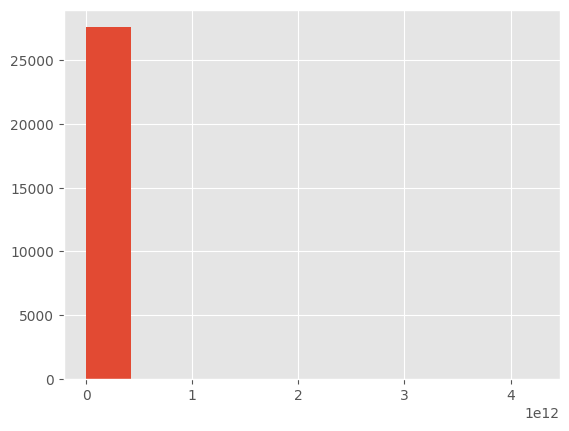

In [ ]:
plt.hist(datos_Cuanti['precio_venta'])

(array([2.756e+04, 0.000e+00, 1.000e+00, 3.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 2.000e+00, 1.000e+00, 0.000e+00, 2.000e+00,
        1.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 1.000e+00,
        0.000e+00, 0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([1.00000000e+06, 8.50009800e+10, 1.70000960e+11, 2.55000940e+11,
        3.40000920e+11, 4.25000900e+11, 5.10000880e+11, 5.95000860e+11,
        6.80000840e+11, 7.65000820e+11, 8.50000800e+11, 9.35000780e+11,
        1.02000076e+12, 1.10500074e+12, 1.19000072e+12, 1.27500070e+12,
        1.36000068e+12, 1.44500066e+12, 1.53000064e+12, 1.61500062e+12,
        1.700000

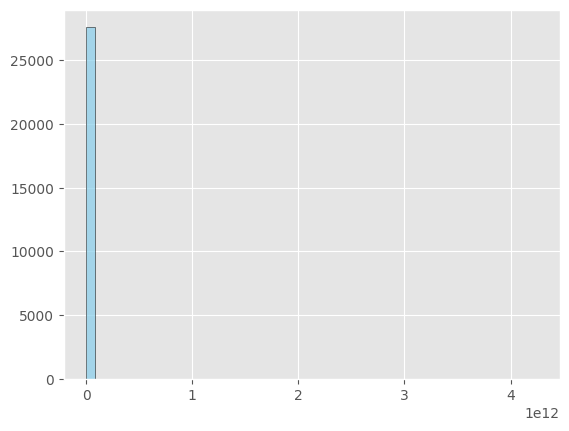

In [ ]:
plt.hist(datos_Cuanti['precio_venta'],
         bins=50,  # Número de bins
         color='skyblue',
         edgecolor='black',
         alpha=0.7)

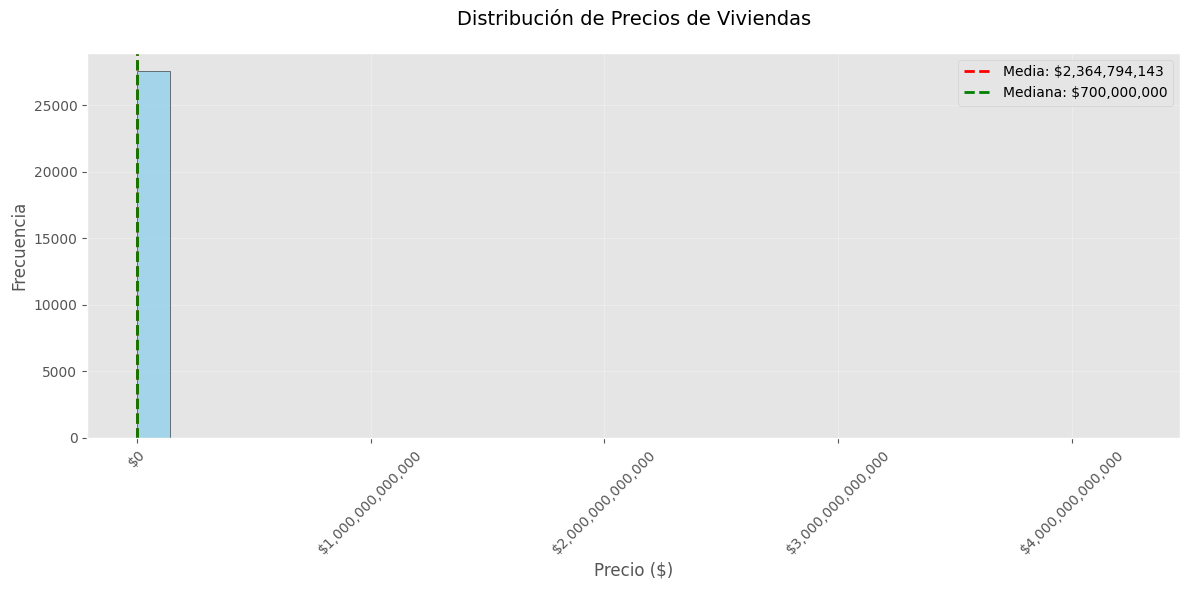

In [ ]:
# Crear la figura y los ejes
plt.figure(figsize=(12, 6))

# Crear el histograma
plt.hist(datos_Cuanti['precio_venta'],
         bins=30,  # Número de bins
         color='skyblue',
         edgecolor='black',
         alpha=0.7)

# Añadir líneas verticales para estadísticas importantes
plt.axvline(datos_Cuanti['precio_venta'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: ${datos_Cuanti["precio_venta"].mean():,.0f}')
plt.axvline(datos_Cuanti['precio_venta'].median(), color='green', linestyle='--', linewidth=2,
            label=f'Mediana: ${datos_Cuanti["precio_venta"].median():,.0f}')

# Personalizar el gráfico
plt.title('Distribución de Precios de Viviendas', pad=20, fontsize=14)
plt.xlabel('Precio ($)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)

# Ajustar formato del eje x para mostrar miles con K
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.xticks(rotation=45)

# Añadir cuadrícula
plt.grid(True, alpha=0.3)

# Añadir leyenda
plt.legend()

# Ajustar márgenes
plt.tight_layout()

# Mostrar el gráfico
plt.show()

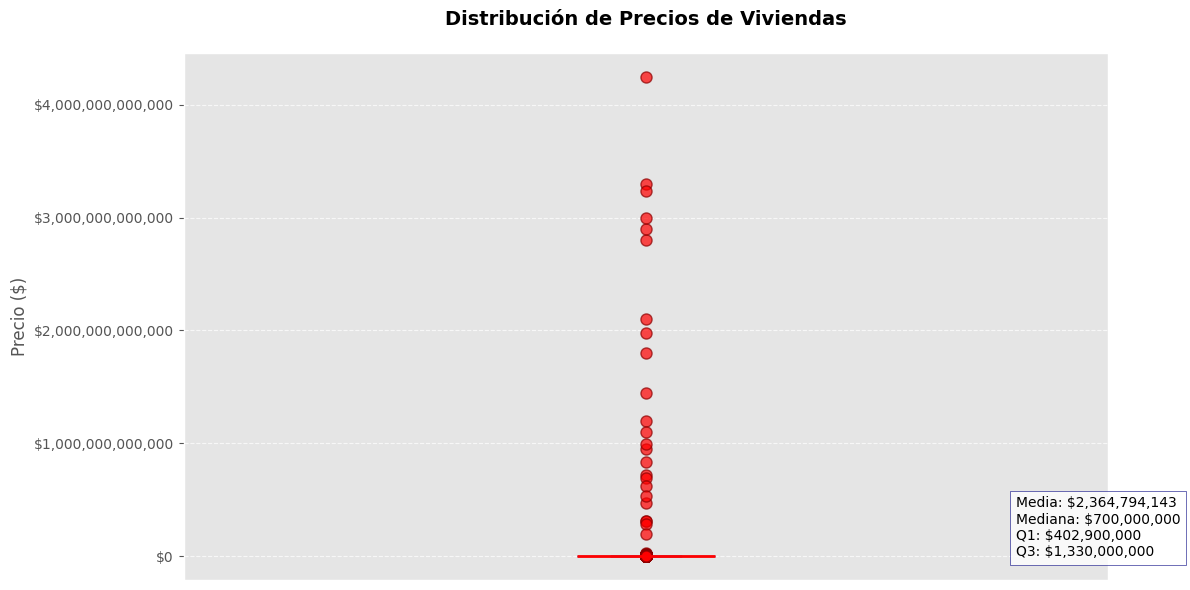

In [ ]:
# Configurar el estilo
fig, ax = plt.subplots(figsize=(12, 6))

# Crear el boxplot
bp = ax.boxplot(datos_Cuanti['precio_venta'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.8, color='navy'),
                whiskerprops=dict(color='navy', linestyle='--'),
                capprops=dict(color='navy'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o',
                              markerfacecolor='red',
                              markeredgecolor='darkred',
                              markersize=8,
                              alpha=0.7))

# Personalizar el gráfico
ax.set_title('Distribución de Precios de Viviendas',
             pad=20,
             fontsize=14,
             fontweight='bold')
ax.set_ylabel('Precio ($)', fontsize=12)

# Añadir grid solo en el eje y
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

# Formatear el eje y para mostrar los precios en miles
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Eliminar el eje x ya que solo tenemos una variable
ax.set_xticks([])

# Añadir un texto con estadísticas clave
stats_text = (f'Media: ${datos_Cuanti["precio_venta"].mean():,.0f}\n'
              f'Mediana: ${datos_Cuanti["precio_venta"].median():,.0f}\n'
              f'Q1: ${datos_Cuanti["precio_venta"].quantile(0.25):,.0f}\n'
              f'Q3: ${datos_Cuanti["precio_venta"].quantile(0.75):,.0f}')

plt.text(1.4, datos_Cuanti["precio_venta"].median(),
         stats_text,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='navy'),
         fontsize=10)

# Ajustar los márgenes
plt.tight_layout()

# Mostrar el gráfico
plt.show()

## Gráficar todas las variables

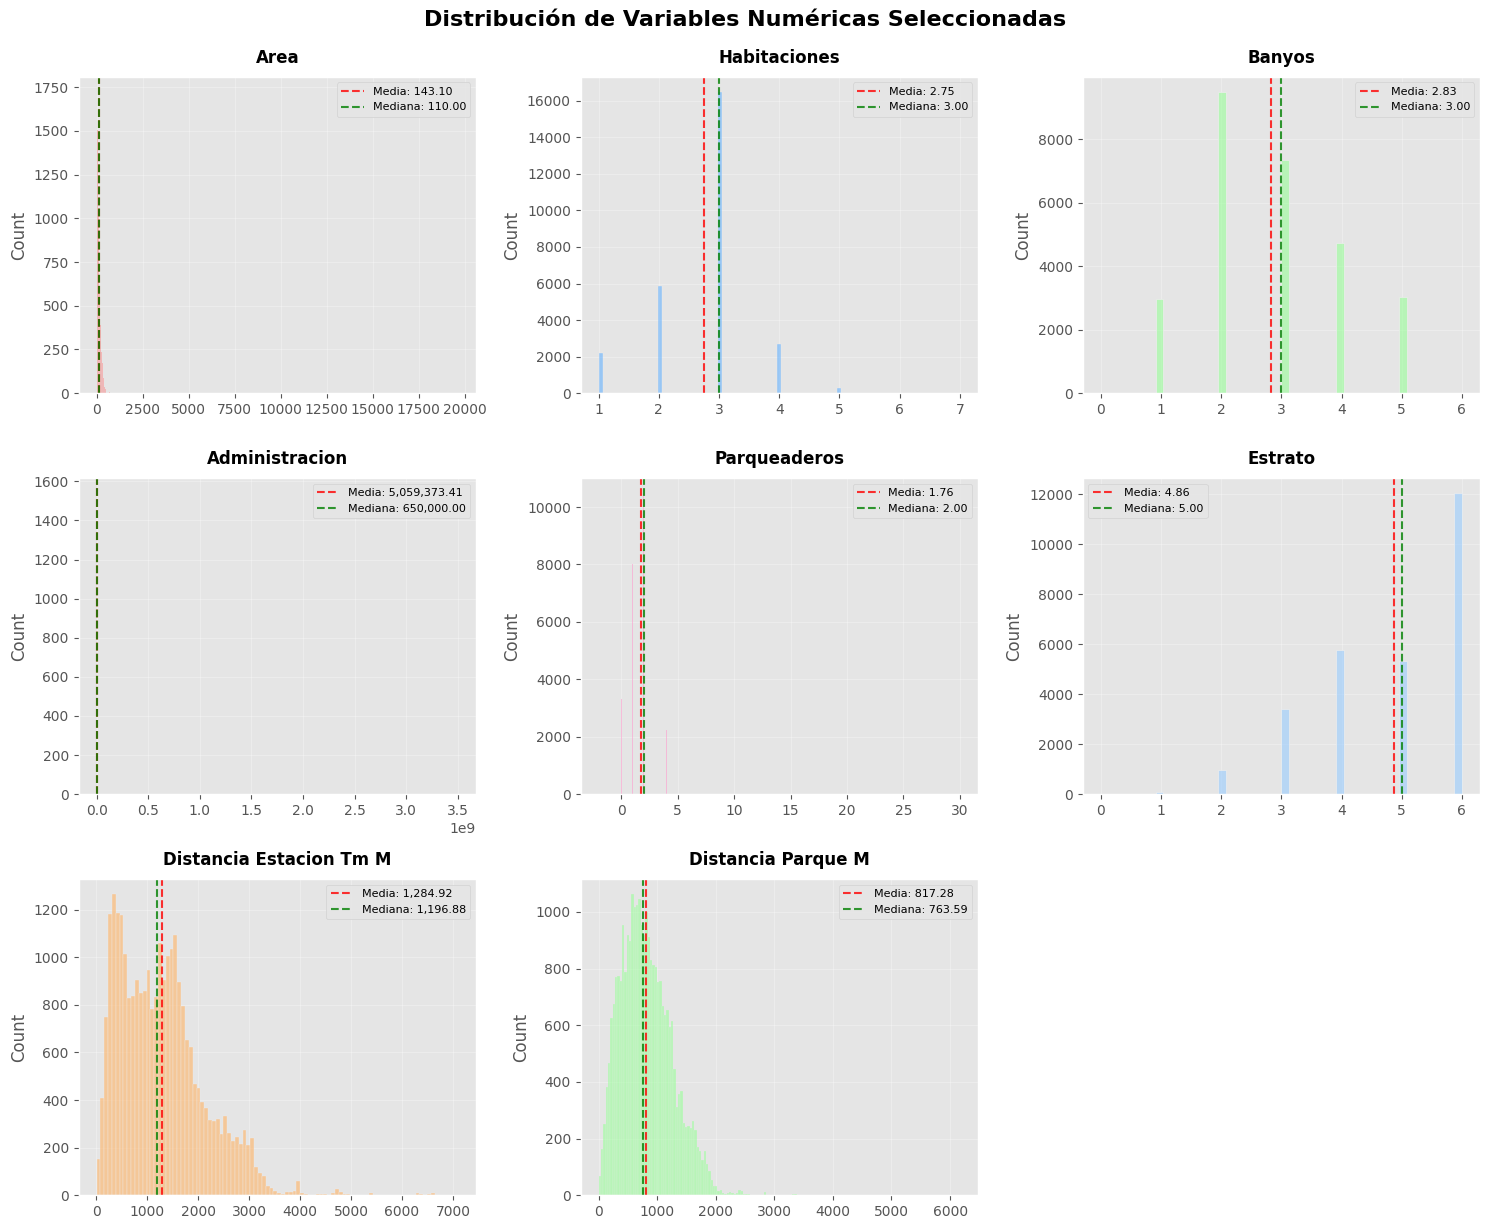

In [ ]:
# Selección de las variables que a graficar
#  ['precio_venta', 'area', 'habitaciones', 'banyos', 'administracion',
#  'parqueaderos', 'estrato', 'distancia_estacion_tm_m',
#  'esta_cerca_estacion_tm', 'distancia_parque_m', 'esta_cerca_parque']

# Excluyendo 'esta_cerca_estacion_tm' y 'esta_cerca_parque' porque son binarias (int64)
# Excluir 'piso' porque tiene todos los valores nulos
# Excluir 'precio_arriendo' por tener muchos nulos y no ser la variable objetivo
# Excluir 'latitud' y 'longitud'

columnas_a_graficar = [
    'area',
    'habitaciones',
    'banyos',
    'administracion',
    'parqueaderos',
    'estrato',
    'distancia_estacion_tm_m',
    'distancia_parque_m'
]

columnas_numeric = [col for col in columnas_a_graficar if col in datos_Cuanti.columns and col != 'precio_venta']


# Determinar el número de filas y columnas para los subplots dinámicamente
num_plots = len(columnas_numeric)
if num_plots == 0:
    print("No se han seleccionado variables numéricas para graficar.")
else:
    ncols = 3 # Mantener 3 columnas por fila
    nrows = (num_plots + ncols - 1) // ncols # Calcular filas necesarias, redondeando hacia arriba

    # Crear subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flat

    # Colores personalizados para cada gráfico (se ciclarán si hay más plots que colores)
    colores = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC',
               '#99CCFF', '#FFB366', '#99FF99', '#FF99FF', '#CCFF99']

    for i, columna in enumerate(columnas_numeric):
        # Crear histograma con kde
        sns.histplot(
            data=datos_Cuanti,
            x=columna,
            stat="count",
            kde=False, # Si se le quiere poner la densidad (True/False)
            color=colores[i % len(colores)], # Ciclar colores
            line_kws={'linewidth': 2, 'color': 'darkblue'},
            alpha=0.6,
            ax=axes[i]
        )

        # Personalizar cada subplot
        axes[i].set_title(columna.replace('_', ' ').title(),
                         fontsize=12,
                         fontweight="bold",
                         pad=10)
        axes[i].tick_params(labelsize=10)
        axes[i].set_xlabel("")
        axes[i].grid(True, alpha=0.3)

        # Añadir estadísticas básicas
        # Asegurarse de que la columna tenga valores no nulos para calcular media/mediana
        if datos_Cuanti[columna].count() > 0:
            media = datos_Cuanti[columna].mean()
            mediana = datos_Cuanti[columna].median()

            # Añadir líneas verticales para media y mediana
            axes[i].axvline(media, color='red', linestyle='--', alpha=0.8,
                            label=f'Media: {media:,.2f}')
            axes[i].axvline(mediana, color='green', linestyle='--', alpha=0.8,
                            label=f'Mediana: {mediana:,.2f}')
            axes[i].legend(fontsize=8)

    # Eliminar subplots vacíos si los hay
    for j in range(num_plots, nrows * ncols):
        fig.delaxes(axes[j])

    # Ajustar layout
    plt.tight_layout()

    # Añadir título general
    fig.suptitle('Distribución de Variables Numéricas Seleccionadas',
                 fontsize=16,
                 fontweight="bold",
                 y=1.02)

    # Mostrar el gráfico
    plt.show()

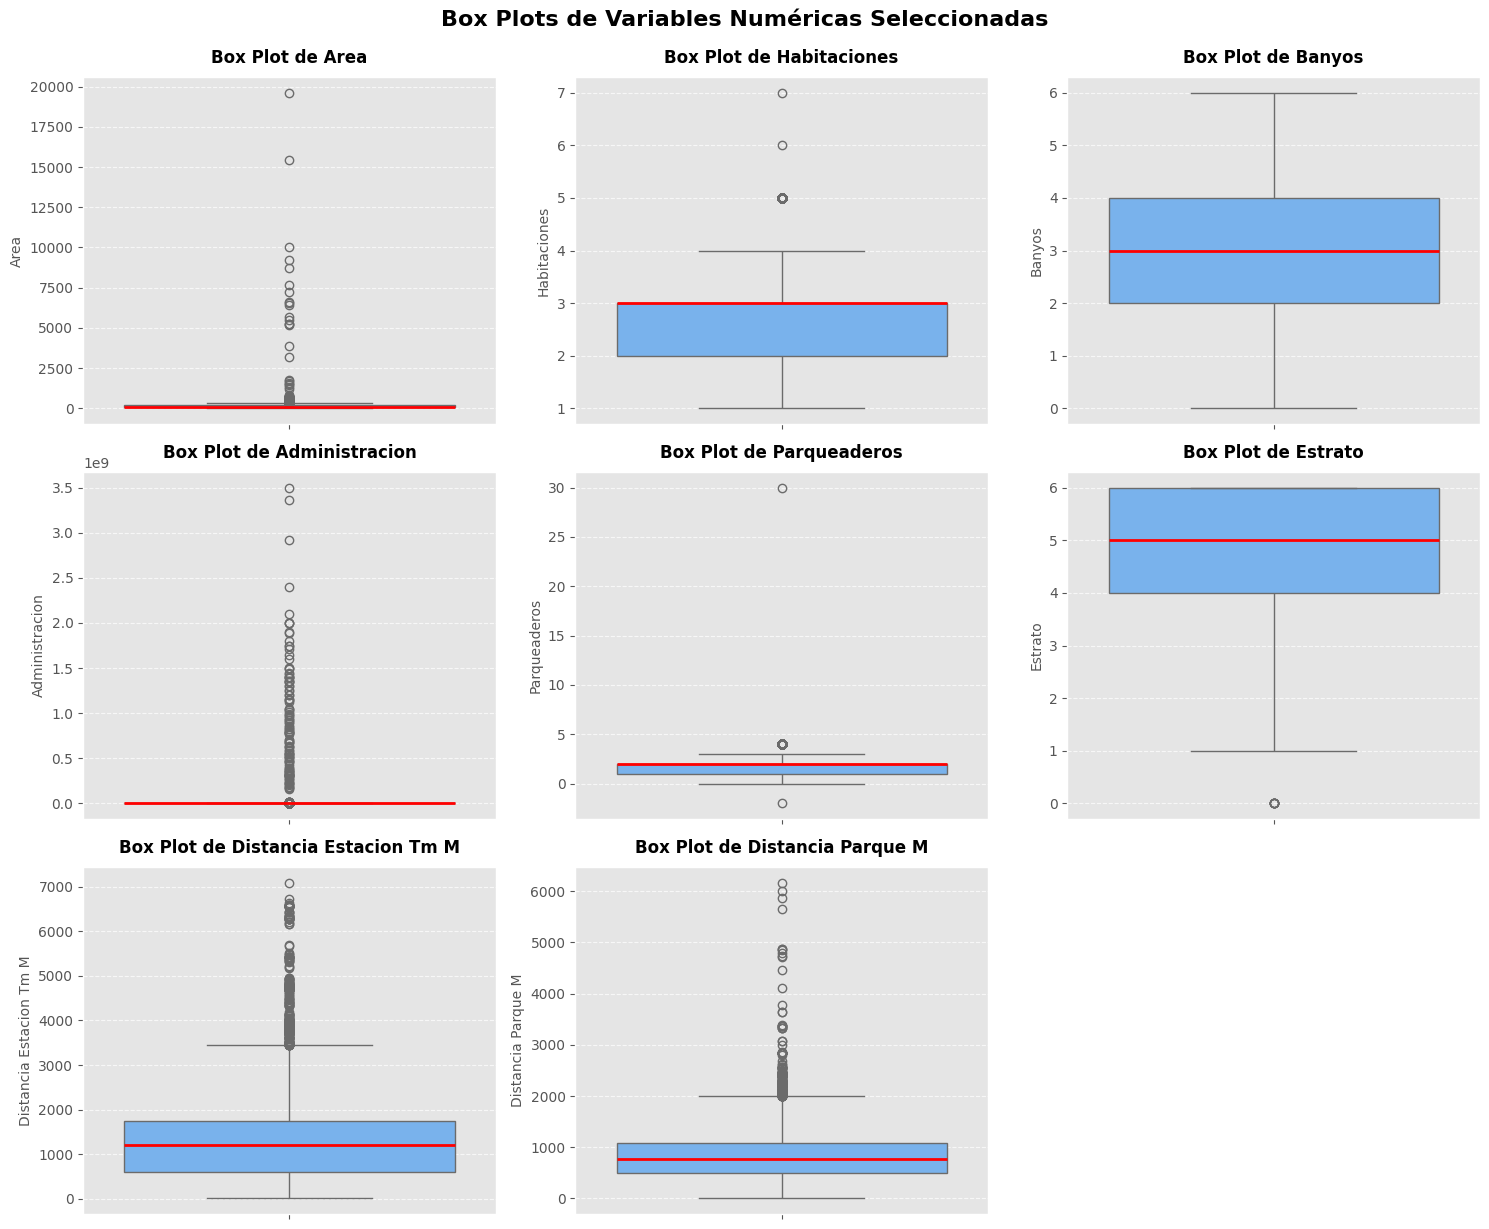

In [ ]:
# Variables a graficar (ya definidas en el paso anterior)
# Estas son las columnas numéricas relevantes para box plots
columnas_para_boxplot = columnas_numeric

# Determinar el número de filas y columnas para los subplots dinámicamente
num_plots_boxplot = len(columnas_para_boxplot)
if num_plots_boxplot == 0:
    print("No hay variables numéricas seleccionadas para los box plots.")
else:
    ncols_boxplot = 3 # Mantener 3 columnas por fila para los box plots
    nrows_boxplot = (num_plots_boxplot + ncols_boxplot - 1) // ncols_boxplot # Calcular filas necesarias

    fig_bp, axes_bp = plt.subplots(nrows_boxplot, ncols_boxplot, figsize=(15, 4 * nrows_boxplot))
    axes_bp = axes_bp.flat

    for i, columna in enumerate(columnas_para_boxplot):
        if datos_Cuanti[columna].count() > 0: # Asegurarse de que haya datos para plotear
            sns.boxplot(
                data=datos_Cuanti,
                y=columna,
                ax=axes_bp[i],
                color='#66B2FF', # Color de la caja
                medianprops={'color': 'red', 'linewidth': 2} # Color de la mediana
            )
            axes_bp[i].set_title(f'Box Plot de {columna.replace("_", " ").title()}',
                               fontsize=12, fontweight="bold", pad=10)
            axes_bp[i].set_ylabel(columna.replace("_", " ").title(), fontsize=10)
            axes_bp[i].tick_params(labelsize=10)
            axes_bp[i].grid(axis='y', linestyle='--', alpha=0.7)
        else:
            axes_bp[i].set_visible(False) # Ocultar subplot si no hay datos

    # Eliminar subplots vacíos si los hay
    for j in range(num_plots_boxplot, nrows_boxplot * ncols_boxplot):
        fig_bp.delaxes(axes_bp[j])

    plt.tight_layout()
    fig_bp.suptitle('Box Plots de Variables Numéricas Seleccionadas',
                    fontsize=16, fontweight="bold", y=1.02)
    plt.show()

#PREPARACIÓN DE LOS DATOS

##Limpieza de Datos

In [ ]:

print("Registros antes de limpieza:", len(datos))

# Calculate total records for percentage calculation
total_records = len(datos)

print("\n--- Porcentaje de Valores problemáticos detectados ---")
print(f"area = 0:              {((datos['area'] == 0).sum() / total_records * 100):.2f}%")
print(f"banyos = 0:            {((datos['banyos'] == 0).sum() / total_records * 100):.2f}%")
print(f"parqueaderos < 0:      {((datos['parqueaderos'] < 0).sum() / total_records * 100):.2f}%")
print(f"parqueaderos > 10:     {((datos['parqueaderos'] > 10).sum() / total_records * 100):.2f}%")
print(f"estrato = 0:           {((datos['estrato'] == 0).sum() / total_records * 100):.2f}%")
print(f"habitaciones = 0:      {((datos['habitaciones'] == 0).sum() / total_records * 100):.2f}%")

Registros antes de limpieza: 27584

--- Porcentaje de Valores problemáticos detectados ---
area = 0:              0.07%
banyos = 0:            0.05%
parqueaderos < 0:      0.00%
parqueaderos > 10:     0.00%
estrato = 0:           0.03%
habitaciones = 0:      0.00%


In [ ]:
# ── PRECIO_VENTA ───────────────────────────────────────────────────────────────
# Corte p99
q99_precio = datos['precio_venta'].quantile(0.99)
datos = datos[datos['precio_venta'] <= q99_precio].copy()

# ── AREA ───────────────────────────────────────────────────────────────────────
# Eliminar ceros (errores de digitación)
datos = datos[datos['area'] > 0].copy()

# Corte p99 (áreas absurdas como 19,621 m2)
q99_area = datos['area'].quantile(0.99)
datos = datos[datos['area'] <= q99_area].copy()

# ── BANYOS ─────────────────────────────────────────────────────────────────────
# Eliminar ceros (no tiene sentido un apto sin baño)
datos = datos[datos['banyos'] > 0].copy()

# ── PARQUEADEROS ───────────────────────────────────────────────────────────────
# Eliminar negativos (errores claros)
datos = datos[datos['parqueaderos'] >= 0].copy()

# Corte p99 (valor máximo de 30 es outlier)
q99_parq = datos['parqueaderos'].quantile(0.99)
datos = datos[datos['parqueaderos'] <= q99_parq].copy()

# ── ESTRATO ────────────────────────────────────────────────────────────────────
# Eliminar estrato 0 (no existe en clasificación oficial)
datos = datos[datos['estrato'] >= 1].copy()

# ── HABITACIONES ───────────────────────────────────────────────────────────────
# Sin limpiar — distribución limpia según descriptivo (min=1, max=7)
# Solo verificar nulos
datos = datos[datos['habitaciones'] >= 1].copy()

# ── DISTANCIAS ─────────────────────────────────────────────────────────────────
# Ambas tienen mínimos coherentes (> 0), sin limpieza de errores
# Solo corte p99 para outliers extremos
q99_tm   = datos['distancia_estacion_tm_m'].quantile(0.99)
q99_parq_dist = datos['distancia_parque_m'].quantile(0.99)

datos = datos[
    (datos['distancia_estacion_tm_m'] <= q99_tm) &
    (datos['distancia_parque_m'] <= q99_parq_dist)
].copy()



In [ ]:
# ── RESUMEN FINAL ──────────────────────────────────────────────────────────────
cols = ['precio_venta', 'area', 'banyos', 'parqueaderos', 'estrato', 'habitaciones', 'distancia_estacion_tm_m', 'distancia_parque_m']
resumen = pd.DataFrame({
    "min": datos[cols].min(),
    "max": datos[cols].max(),
    "nulos": datos[cols].isnull().sum()
})
print(resumen)

                                 min              max  nulos
precio_venta            1,000,000.00 5,428,654,000.00      0
area                            1.00           430.00      0
banyos                          1.00             6.00      0
parqueaderos                    0.00             4.00      0
estrato                         1.00             6.00      0
habitaciones                    1.00             7.00      0
distancia_estacion_tm_m         4.94         3,522.16      0
distancia_parque_m              0.22         1,899.92      0


Registros antes de limpieza: 27584

Registros después de limpieza: 25499

Registros eliminados: 2.085 - 7.55%

## Transformación de Datos


Se realiza transformación a:
* Precio_Venta y area 	 por Asimetria extrema y Outliers severos

* distancia_estacion_tm_m: Asimetria moderada. CV alto (54-66%) y Outliers leves

In [ ]:
# Variables numéricas
# ==============================================================================
datos_Cuanti = datos.select_dtypes(include=['float64', 'int'])

In [ ]:
datos_Cuanti.describe().round(2)

,precio_venta,area,habitaciones,banyos,administracion,parqueaderos,estrato,latitud,longitud,precio_arriendo,piso,closets,distancia_estacion_tm_m,distancia_parque_m
count,"27,584.00","27,584.00","27,583.00","27,583.00","25,140.00","27,583.00","27,583.00","27,584.00","27,584.00",403.00,0.00,0.00,"27,584.00","27,584.00"
mean,"2,364,794,142.84",143.10,2.75,2.83,"5,059,373.41",1.76,4.86,4.69,-74.06,"84,015,781.64",<NA>,<NA>,"1,284.92",817.28
std,"55,741,976,390.87",234.38,0.78,1.17,"76,482,423.61",1.09,1.22,0.04,0.03,"990,569,856.23",<NA>,<NA>,843.64,444.19
min,"1,000,000.00",0.00,1.00,0.00,1.00,-2.00,0.00,4.47,-74.21,"740,000.00",<NA>,<NA>,4.94,0.22
25%,"402,900,000.00",69.00,2.00,2.00,"350,000.00",1.00,4.00,4.67,-74.07,"4,480,000.00",<NA>,<NA>,587.03,489.67
50%,"700,000,000.00",110.00,3.00,3.00,"650,000.00",2.00,5.00,4.69,-74.05,"7,500,000.00",<NA>,<NA>,"1,196.88",763.59
75%,"1,330,000,000.00",180.00,3.00,4.00,"1,199,550.00",2.00,6.00,4.72,-74.04,"12,000,000.00",<NA>,<NA>,"1,732.09","1,091.23"
max,"4,250,000,000,000.00","19,621.00",7.00,6.00,"3,500,000,000.00",30.00,6.00,4.82,-74.01,"18,000,000,000.00",<NA>,<NA>,"7,095.66","6,168.02"


## Transformación Precio_Venta

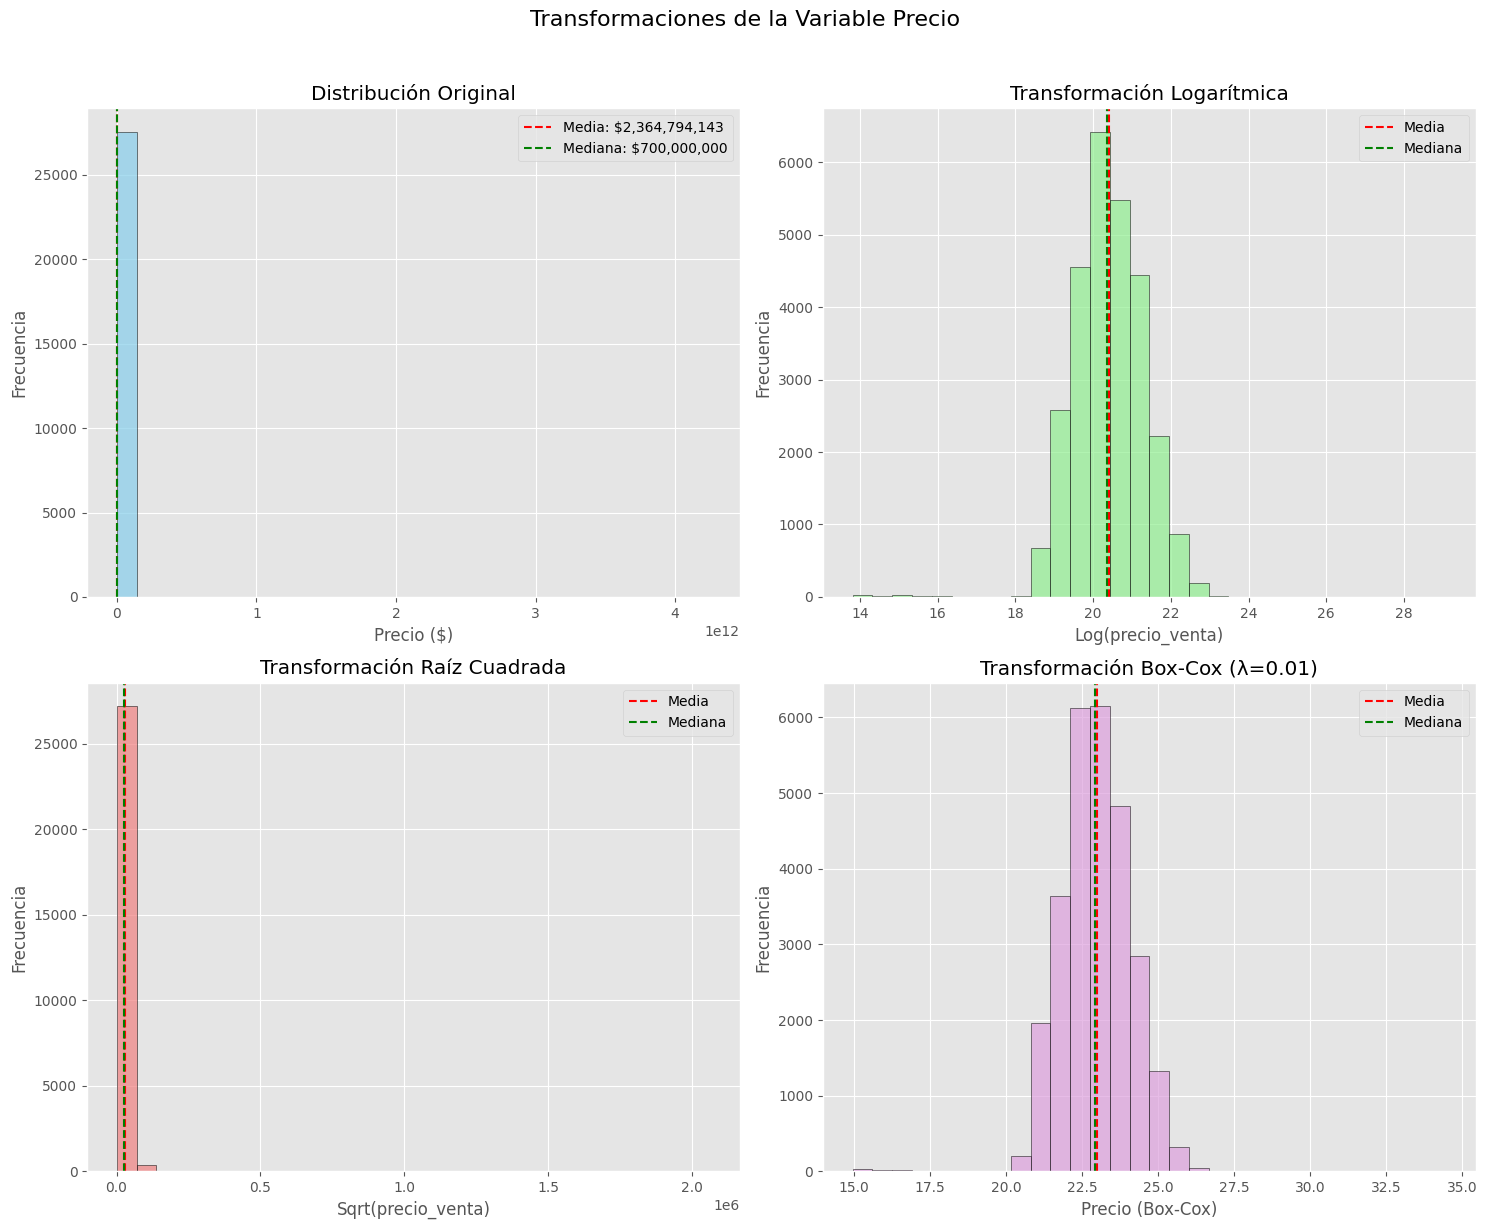


Estadísticas de Asimetría:
Original: 52.770
Logarítmica: -0.119
Raíz Cuadrada: 33.840
Box-Cox: 0.025


In [ ]:
# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Transformaciones de la Variable Precio', fontsize=16, y=1.02)

# Aplanar axes para iterar más fácilmente
axes = axes.ravel()

# 1. Distribución Original
axes[0].hist(datos_Cuanti['precio_venta'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(datos_Cuanti['precio_venta'].mean(), color='red', linestyle='--', label=f'Media: ${datos_Cuanti["precio_venta"].mean():,.0f}')
axes[0].axvline(datos_Cuanti['precio_venta'].median(), color='green', linestyle='--', label=f'Mediana: ${datos_Cuanti["precio_venta"].median():,.0f}')
axes[0].set_title('Distribución Original')
axes[0].set_xlabel('Precio ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# 2. Transformación Logarítmica
axes[1].hist(np.log(datos_Cuanti['precio_venta']), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(np.log(datos_Cuanti['precio_venta']).mean(), color='red', linestyle='--', label='Media')
axes[1].axvline(np.log(datos_Cuanti['precio_venta']).median(), color='green', linestyle='--', label='Mediana')
axes[1].set_title('Transformación Logarítmica')
axes[1].set_xlabel('Log(precio_venta)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3. Transformación Raíz Cuadrada
axes[2].hist(np.sqrt(datos_Cuanti['precio_venta']), bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[2].axvline(np.sqrt(datos_Cuanti['precio_venta']).mean(), color='red', linestyle='--', label='Media')
axes[2].axvline(np.sqrt(datos_Cuanti['precio_venta']).median(), color='green', linestyle='--', label='Mediana')
axes[2].set_title('Transformación Raíz Cuadrada')
axes[2].set_xlabel('Sqrt(precio_venta)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

# 4. Transformación Box-Cox
from scipy import stats
precio_boxcox, lambda_param = stats.boxcox(datos_Cuanti['precio_venta'])
axes[3].hist(precio_boxcox, bins=30, color='plum', edgecolor='black', alpha=0.7)
axes[3].axvline(precio_boxcox.mean(), color='red', linestyle='--', label='Media')
axes[3].axvline(np.median(precio_boxcox), color='green', linestyle='--', label='Mediana')
axes[3].set_title(f'Transformación Box-Cox (λ={lambda_param:.2f})')
axes[3].set_xlabel('Precio (Box-Cox)')
axes[3].set_ylabel('Frecuencia')
axes[3].legend()

# Ajustar layout
plt.tight_layout()
plt.show()

# Imprimir estadísticas de asimetría para cada transformación
print("\nEstadísticas de Asimetría:")
print(f"Original: {stats.skew(datos_Cuanti['precio_venta']):.3f}")
print(f"Logarítmica: {stats.skew(np.log(datos_Cuanti['precio_venta'])):.3f}")
print(f"Raíz Cuadrada: {stats.skew(np.sqrt(datos_Cuanti['precio_venta'])):.3f}")
print(f"Box-Cox: {stats.skew(precio_boxcox):.3f}")


1. *Original*: 1.602

- Distribución con fuerte sesgo positivo. La mayoría de los valores están concentrados en la parte baja, pero hay outliers muy altos que estiran la cola derecha (ej. precios o áreas gigantes).

2. *Logarítmica*: -0.956

- Al aplicar logaritmo, la distribución se “comprime” en la cola derecha.
- El sesgo se invierte: ahora hay ligera asimetría negativa, con más peso en valores bajos.
- Útil cuando los datos tienen rangos muy grandes y outliers altos.

3. *Raíz Cuadrada*: 0.769

- La transformación suaviza la cola derecha, pero no tanto como el logaritmo.
- La asimetría positiva se reduce, pero sigue presente.
- Es una corrección parcial, útil cuando los datos no son tan extremos.

4. *Box-Cox*: 0.046

- La transformación Box-Cox busca automáticamente el mejor parámetro para “normalizar” la distribución.
- El resultado es casi simétrico (muy cercano a 0).
- Es la transformación más efectiva en este caso, porque logra que la variable se acerque a una distribución normal.


##Transformación Area

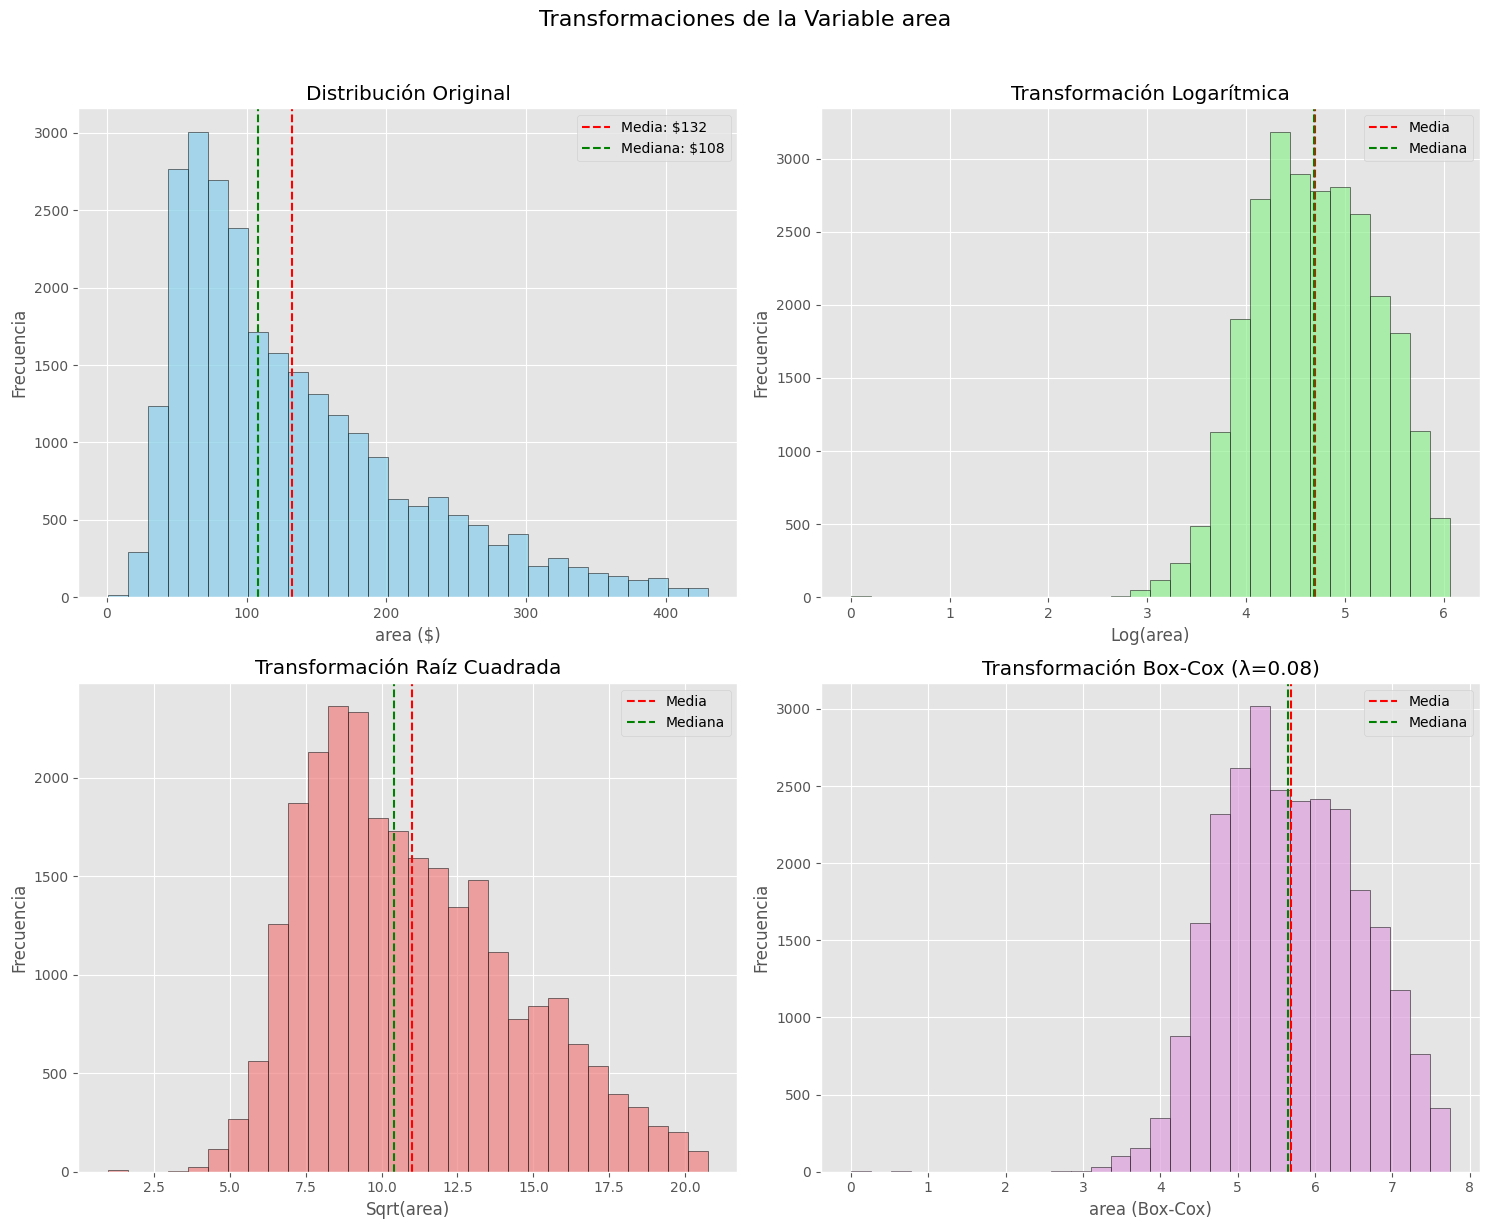


Estadísticas de Asimetría:
Original: 1.139
Logarítmica: -0.150
Raíz Cuadrada: 0.571
Box-Cox: -0.002


In [ ]:
# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Transformaciones de la Variable area', fontsize=16, y=1.02)

# Aplanar axes para iterar más fácilmente
axes = axes.ravel()

# 1. Distribución Original
axes[0].hist(datos_Cuanti['area'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(datos_Cuanti['area'].mean(), color='red', linestyle='--', label=f'Media: ${datos_Cuanti["area"].mean():,.0f}')
axes[0].axvline(datos_Cuanti['area'].median(), color='green', linestyle='--', label=f'Mediana: ${datos_Cuanti["area"].median():,.0f}')
axes[0].set_title('Distribución Original')
axes[0].set_xlabel('area ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# 2. Transformación Logarítmica
axes[1].hist(np.log(datos_Cuanti['area']), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(np.log(datos_Cuanti['area']).mean(), color='red', linestyle='--', label='Media')
axes[1].axvline(np.log(datos_Cuanti['area']).median(), color='green', linestyle='--', label='Mediana')
axes[1].set_title('Transformación Logarítmica')
axes[1].set_xlabel('Log(area)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3. Transformación Raíz Cuadrada
axes[2].hist(np.sqrt(datos_Cuanti['area']), bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[2].axvline(np.sqrt(datos_Cuanti['area']).mean(), color='red', linestyle='--', label='Media')
axes[2].axvline(np.sqrt(datos_Cuanti['area']).median(), color='green', linestyle='--', label='Mediana')
axes[2].set_title('Transformación Raíz Cuadrada')
axes[2].set_xlabel('Sqrt(area)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

# 4. Transformación Box-Cox
from scipy import stats
precio_boxcox, lambda_param = stats.boxcox(datos_Cuanti['area'])
axes[3].hist(precio_boxcox, bins=30, color='plum', edgecolor='black', alpha=0.7)
axes[3].axvline(precio_boxcox.mean(), color='red', linestyle='--', label='Media')
axes[3].axvline(np.median(precio_boxcox), color='green', linestyle='--', label='Mediana')
axes[3].set_title(f'Transformación Box-Cox (λ={lambda_param:.2f})')
axes[3].set_xlabel('area (Box-Cox)')
axes[3].set_ylabel('Frecuencia')
axes[3].legend()

# Ajustar layout
plt.tight_layout()
plt.show()

# Imprimir estadísticas de asimetría para cada transformación
print("\nEstadísticas de Asimetría:")
print(f"Original: {stats.skew(datos_Cuanti['area']):.3f}")
print(f"Logarítmica: {stats.skew(np.log(datos_Cuanti['area'])):.3f}")
print(f"Raíz Cuadrada: {stats.skew(np.sqrt(datos_Cuanti['area'])):.3f}")
print(f"Box-Cox: {stats.skew(precio_boxcox):.3f}")

- *Original*: 1.015

- La distribución tiene un sesgo positivo moderado. La cola derecha (valores altos) todavía pesa bastante, aunque no es tan extremo como el 1.6 que tenías antes.

- *Logarítmica:* -0.215

- La transformación logarítmica redujo el sesgo positivo y lo llevó a un sesgo negativo leve. Esto significa que ahora la distribución se inclina un poco hacia la izquierda, pero está bastante cerca de la simetría.

- *Raíz Cuadrada*: 0.491

- La raíz cuadrada suaviza la cola derecha, pero no tanto como el logaritmo. El sesgo positivo se reduce a un nivel moderado, aunque sigue presente.

- *Box-Cox*: -0.004

- Prácticamente simétrica. El valor está muy cercano a 0, lo que indica que la distribución se normalizó casi por completo. Es la transformación más efectiva en este caso.


##Transformación Distancia Transmilenio

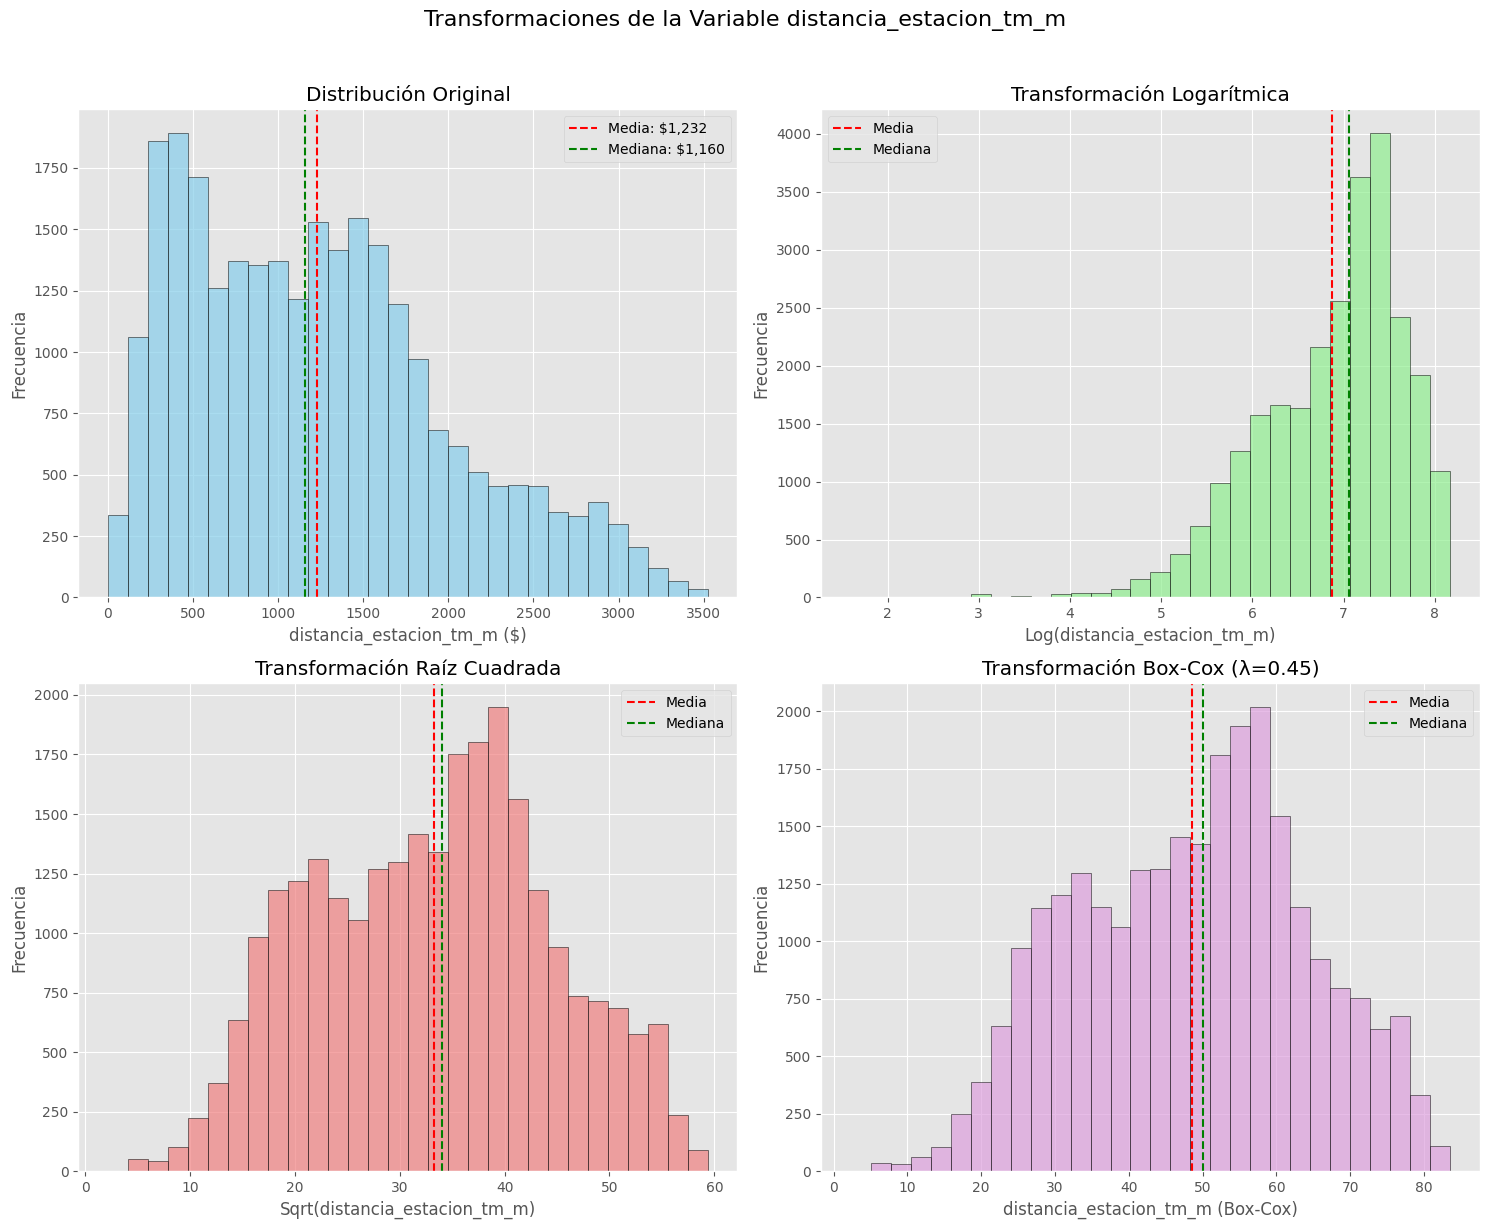


Estadísticas de Asimetría:
Original: 0.608
Logarítmica: -0.903
Raíz Cuadrada: -0.015
Box-Cox: -0.090


In [ ]:
# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Transformaciones de la Variable distancia_estacion_tm_m', fontsize=16, y=1.02)

# Aplanar axes para iterar más fácilmente
axes = axes.ravel()

# 1. Distribución Original
axes[0].hist(datos_Cuanti['distancia_estacion_tm_m'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(datos_Cuanti['distancia_estacion_tm_m'].mean(), color='red', linestyle='--', label=f'Media: ${datos_Cuanti["distancia_estacion_tm_m"].mean():,.0f}')
axes[0].axvline(datos_Cuanti['distancia_estacion_tm_m'].median(), color='green', linestyle='--', label=f'Mediana: ${datos_Cuanti["distancia_estacion_tm_m"].median():,.0f}')
axes[0].set_title('Distribución Original')
axes[0].set_xlabel('distancia_estacion_tm_m ($)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# 2. Transformación Logarítmica
axes[1].hist(np.log(datos_Cuanti['distancia_estacion_tm_m']), bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].axvline(np.log(datos_Cuanti['distancia_estacion_tm_m']).mean(), color='red', linestyle='--', label='Media')
axes[1].axvline(np.log(datos_Cuanti['distancia_estacion_tm_m']).median(), color='green', linestyle='--', label='Mediana')
axes[1].set_title('Transformación Logarítmica')
axes[1].set_xlabel('Log(distancia_estacion_tm_m)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

# 3. Transformación Raíz Cuadrada
axes[2].hist(np.sqrt(datos_Cuanti['distancia_estacion_tm_m']), bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
axes[2].axvline(np.sqrt(datos_Cuanti['distancia_estacion_tm_m']).mean(), color='red', linestyle='--', label='Media')
axes[2].axvline(np.sqrt(datos_Cuanti['distancia_estacion_tm_m']).median(), color='green', linestyle='--', label='Mediana')
axes[2].set_title('Transformación Raíz Cuadrada')
axes[2].set_xlabel('Sqrt(distancia_estacion_tm_m)')
axes[2].set_ylabel('Frecuencia')
axes[2].legend()

# 4. Transformación Box-Cox
from scipy import stats
precio_boxcox, lambda_param = stats.boxcox(datos_Cuanti['distancia_estacion_tm_m'])
axes[3].hist(precio_boxcox, bins=30, color='plum', edgecolor='black', alpha=0.7)
axes[3].axvline(precio_boxcox.mean(), color='red', linestyle='--', label='Media')
axes[3].axvline(np.median(precio_boxcox), color='green', linestyle='--', label='Mediana')
axes[3].set_title(f'Transformación Box-Cox (λ={lambda_param:.2f})')
axes[3].set_xlabel('distancia_estacion_tm_m (Box-Cox)')
axes[3].set_ylabel('Frecuencia')
axes[3].legend()

# Ajustar layout
plt.tight_layout()
plt.show()

# Imprimir estadísticas de asimetría para cada transformación
print("\nEstadísticas de Asimetría:")
print(f"Original: {stats.skew(datos_Cuanti['distancia_estacion_tm_m']):.3f}")
print(f"Logarítmica: {stats.skew(np.log(datos_Cuanti['distancia_estacion_tm_m'])):.3f}")
print(f"Raíz Cuadrada: {stats.skew(np.sqrt(datos_Cuanti['distancia_estacion_tm_m'])):.3f}")
print(f"Box-Cox: {stats.skew(precio_boxcox):.3f}")

- *Original*: 0.553

- La distribución tiene un sesgo positivo leve. No es tan grave, pero todavía indica que hay más valores altos que estiran la cola derecha.

- *Logarítmica*: -0.911

- Corrige el sesgo positivo, pero ahora la distribución se inclina hacia la izquierda (sesgo negativo moderado). Puede ser útil en algunos contextos, pero no es lo más balanceado.

- *Raíz Cuadrada*: -0.041

- Prácticamente simétrica. El sesgo es casi nulo, lo que significa que la distribución se acerca bastante a la normalidad.

- *Box-Cox*: -0.098
- También muy cercana a la simetría, con un sesgo negativo muy leve. Es la transformación más “matemáticamente óptima” porque ajusta automáticamente el parámetro para normalizar.


##Reemplazar la variable original con la transformación elegida


In [ ]:
#guardar la transformación Box-Cox en el DataFrame
datos_Cuanti["precio_boxcox"], lambda_bc = stats.boxcox(datos_Cuanti["precio_venta"])
datos_Cuanti["area_boxcox"], lambda_bc = stats.boxcox(datos_Cuanti["area"])
datos_Cuanti["distancia_estacion_tm_m_boxcox"], lambda_bc = stats.boxcox(datos_Cuanti["distancia_estacion_tm_m"])

# Si decides reemplazar la original con Box-Cox
#datos_Cuanti["precio_venta"] = datos_Cuanti["precio_boxcox"]

# (Opcional) eliminar la columna auxiliar
#datos_Cuanti = datos_Cuanti.drop(columns=["precio_boxcox"])


##Análisis de dos variables

In [ ]:
# Seleccionar solo las variables numéricas y excluir 'piso' y  'closets' no hay datos
variables_numericas = datos_Cuanti.select_dtypes(include=['float64', 'int']).drop(columns=['piso', 'closets'], errors='ignore')

In [ ]:
variables_numericas.corr().round(2)

,precio_venta,area,habitaciones,banyos,administracion,parqueaderos,estrato,latitud,longitud,precio_arriendo,distancia_estacion_tm_m,distancia_parque_m,precio_boxcox,area_boxcox,distancia_estacion_tm_m_boxcox
precio_venta,1.00,0.86,0.37,0.70,0.04,0.73,0.58,-0.10,0.35,0.10,0.14,0.01,0.91,0.80,0.15
area,0.86,1.00,0.55,0.80,0.05,0.77,0.60,-0.02,0.37,0.10,0.15,0.07,0.85,0.95,0.16
habitaciones,0.37,0.55,1.00,0.56,0.02,0.40,0.14,0.12,0.03,0.08,0.11,0.01,0.38,0.59,0.12
banyos,0.70,0.80,0.56,1.00,0.04,0.74,0.61,0.07,0.40,0.08,0.11,0.10,0.77,0.84,0.12
administracion,0.04,0.05,0.02,0.04,1.00,0.03,0.03,-0.00,0.01,-0.00,-0.00,0.02,0.04,0.05,-0.00
parqueaderos,0.73,0.77,0.40,0.74,0.03,1.00,0.67,0.07,0.46,0.10,0.09,0.12,0.79,0.80,0.10
estrato,0.58,0.60,0.14,0.61,0.03,0.67,1.00,0.08,0.63,-0.01,0.06,0.19,0.71,0.67,0.08
latitud,-0.10,-0.02,0.12,0.07,-0.00,0.07,0.08,1.00,0.41,-0.01,0.19,0.09,-0.04,0.03,0.19
longitud,0.35,0.37,0.03,0.40,0.01,0.46,0.63,0.41,1.00,0.06,0.12,0.19,0.47,0.43,0.13
precio_arriendo,0.10,0.10,0.08,0.08,-0.00,0.10,-0.01,-0.01,0.06,1.00,0.12,0.07,0.06,0.08,0.10


In [ ]:
# Calcular la matriz de correlación
matriz_corr = variables_numericas.corr()
matriz_corr

,precio_venta,area,habitaciones,banyos,administracion,parqueaderos,estrato,latitud,longitud,precio_arriendo,distancia_estacion_tm_m,distancia_parque_m,precio_boxcox,area_boxcox,distancia_estacion_tm_m_boxcox
precio_venta,1.00,0.86,0.37,0.70,0.04,0.73,0.58,-0.10,0.35,0.10,0.14,0.01,0.91,0.80,0.15
area,0.86,1.00,0.55,0.80,0.05,0.77,0.60,-0.02,0.37,0.10,0.15,0.07,0.85,0.95,0.16
habitaciones,0.37,0.55,1.00,0.56,0.02,0.40,0.14,0.12,0.03,0.08,0.11,0.01,0.38,0.59,0.12
banyos,0.70,0.80,0.56,1.00,0.04,0.74,0.61,0.07,0.40,0.08,0.11,0.10,0.77,0.84,0.12
administracion,0.04,0.05,0.02,0.04,1.00,0.03,0.03,-0.00,0.01,-0.00,-0.00,0.02,0.04,0.05,-0.00
parqueaderos,0.73,0.77,0.40,0.74,0.03,1.00,0.67,0.07,0.46,0.10,0.09,0.12,0.79,0.80,0.10
estrato,0.58,0.60,0.14,0.61,0.03,0.67,1.00,0.08,0.63,-0.01,0.06,0.19,0.71,0.67,0.08
latitud,-0.10,-0.02,0.12,0.07,-0.00,0.07,0.08,1.00,0.41,-0.01,0.19,0.09,-0.04,0.03,0.19
longitud,0.35,0.37,0.03,0.40,0.01,0.46,0.63,0.41,1.00,0.06,0.12,0.19,0.47,0.43,0.13
precio_arriendo,0.10,0.10,0.08,0.08,-0.00,0.10,-0.01,-0.01,0.06,1.00,0.12,0.07,0.06,0.08,0.10


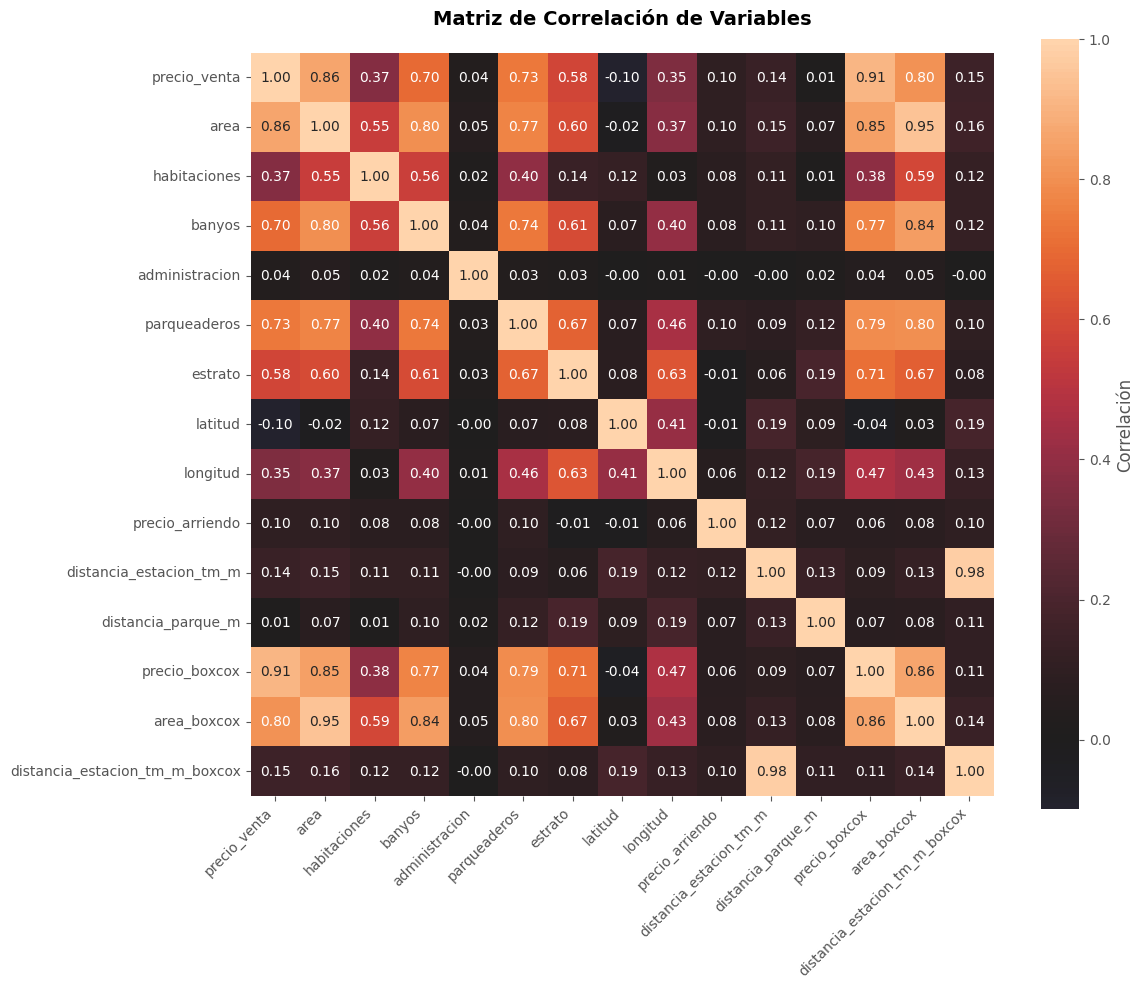


Correlaciones más fuertes con el precio:
precio_venta                      1.00
precio_boxcox                     0.91
area                              0.86
area_boxcox                       0.80
parqueaderos                      0.73
banyos                            0.70
estrato                           0.58
habitaciones                      0.37
longitud                          0.35
distancia_estacion_tm_m_boxcox    0.15
distancia_estacion_tm_m           0.14
precio_arriendo                   0.10
administracion                    0.04
distancia_parque_m                0.01
latitud                          -0.10
Name: precio_venta, dtype: float64

Correlaciones más fuertes con el precio_boxcox:
precio_boxcox                     1.00
precio_venta                      0.91
area_boxcox                       0.86
area                              0.85
parqueaderos                      0.79
banyos                            0.77
estrato                           0.71
longitud        

In [ ]:
# Crear la visualización
plt.figure(figsize=(12, 10))
# Crear el heatmap
sns.heatmap(matriz_corr,
            annot=True,  # Mostrar valores
            # cmap='RdBu',  # Mapa de colores rojo-azul
            center=0,     # Centrar el mapa de colores en 0
            fmt='.2f',    # Formato de números con 2 decimales
            square=True,  # Hacer las celdas cuadradas
            cbar_kws={'label': 'Correlación'})

# Personalizar el gráfico
plt.title('Matriz de Correlación de Variables',
          pad=20,
          fontsize=14,
          fontweight='bold')

# Rotar las etiquetas del eje x para mejor legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Ajustar layout
plt.tight_layout()

# Mostrar el gráfico
plt.show()

# También podemos imprimir las correlaciones más fuertes con el precio
print("\nCorrelaciones más fuertes con el precio:")
correlaciones_precio = matriz_corr['precio_venta'].sort_values(ascending=False)
print(correlaciones_precio)

# También podemos imprimir las correlaciones más fuertes con el precio_boxcox
print("\nCorrelaciones más fuertes con el precio_boxcox:")
correlaciones_precio = matriz_corr['precio_boxcox'].sort_values(ascending=False)
print(correlaciones_precio)

# Precio_venta / Precio_boxcox

## Correlaciones Fuertes (>0.6)
 * area: (0.83) / (0.85)
 * parqueaderos(0.73) / (0.79)
 * banyos(0.70) / (0.71)
 * estrato () / (0.71)

## Correlaciones Moderadas (0.4-0.6)
 * estrato (0.58) / ()
 * longitud () / (0.47)

## Correlaciones Débiles (<0.4)
 * habitaciones(0.37) / (0.38)
 * longitud(0.35) / ()
 * distancia_estacion_tm_m_boxcox(0.15) / (0.11)
 * distancia_estacion_tm_m (0.14) / (0.09)
 * precio_arriendo (0.10) / (0.06)
 * administracion (0.04) / (0.04)
 * distancia_parque_m (0.01) / (0.07)
 * latitud (-0.10) / (-0.4)


### 2. Otras Correlaciones Importantes

#### Entre Características Físicas
* area - parqueaderos (0.77) correlación fuerte
* area_boxcox - parqueaderos (0.80) correlación fuerte
* area - banyos (0.80) correlación fuerte
* area_boxcox - banyos (0.84) correlación fuerte
* area - estrato (0.60):  **correlación moderada**
* area_boxcox - estrato (0.67) **Correlación moderada**
* Parqueadero  - Baños (0.74) correlación fuerte
* Parqueadero - Estrato (0.67) **Correlación moderada**
* banyos- Estrato (0.61) **Correlación moderada**


#### Correlaciones Negativas
* latitud (-0.04)

### 3. Conclusiones para el Modelo
##Variables Más Relevantes:
Son las que más influyen en el precio

*   Area *Más influyecte
*   Parqueadero *Multicolinealidad con Baño
*   Baños *Multicolinealidad con Parqueadero
*   Estrato
Menos influye en el precio
*   longitud
*   Habitaciones
## Multicolinealidad Potencial:

Observar la alta correlación entre baños y parqueaderos
Podría ser necesario seleccionar entre variables altamente correlacionadas

##Variables Menos Relevantes:

*   Esta cerca de estación de TM
*   Esta cerca de un parque
*   Distación estación TM
*   Distacia estación parque

### Tienen menor impacto en el precio

##Conclusiones:
1. La transformación Box-Cox mejora las correlaciones de las variables
2. Area ya tiene correlación alta sin transformar (0.86), lo que confirma que su relación con el precio es casi lineal después de limpiar outliers. La transformación no aporta mucho aquí.
3. Variables a descartar del modelo — administracion (0.04), distancia_parque_m (0.07) y latitud (-0.04) tienen correlaciones tan bajas que aportan ruido más que información.

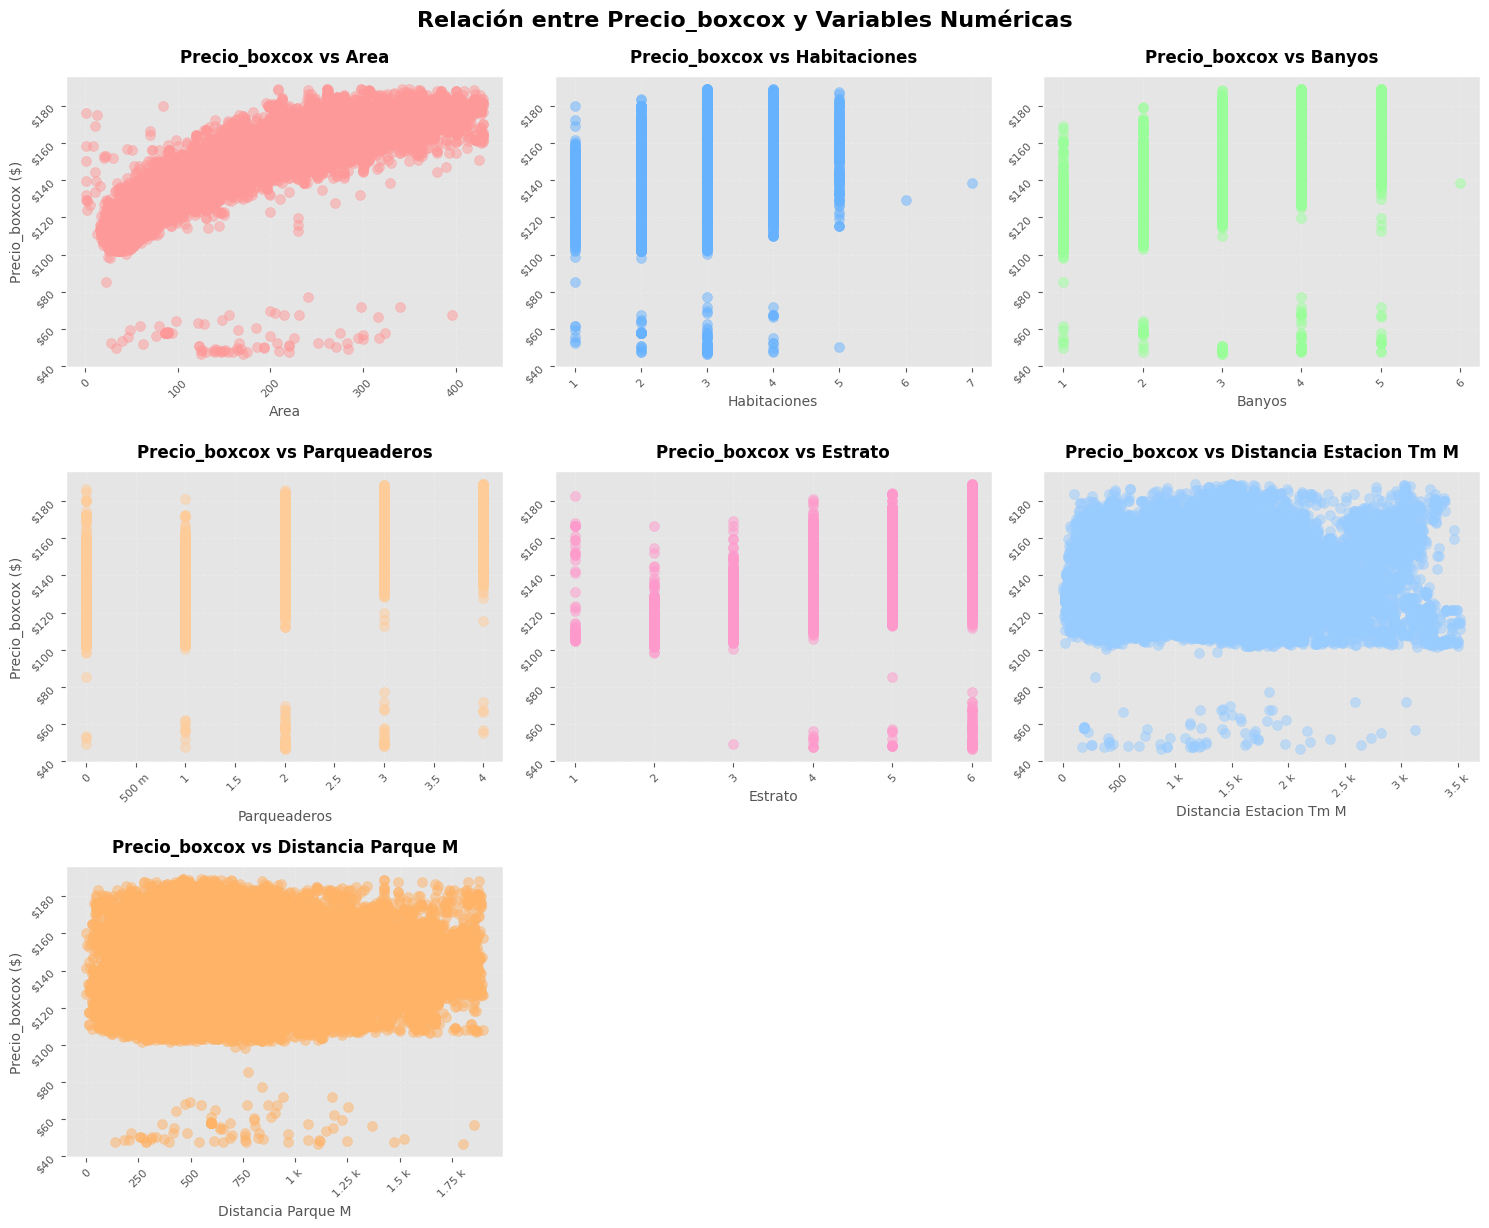

In [ ]:
# Seleccionar variables numérica
# Reutilizamos la lista de columnas seleccionadas previamente para otros gráficos
columnas_a_graficar_scatter = [
    'area',
    'habitaciones',
    'banyos',
    'parqueaderos',
    'estrato',
    'distancia_estacion_tm_m',
    'distancia_parque_m'
]
columnas_numeric = [col for col in columnas_a_graficar_scatter if col in datos_Cuanti.columns and col != 'precio_boxcox']

# Determinar el número de filas y columnas para los subplots dinámicamente
num_plots = len(columnas_numeric)
if num_plots == 0:
    print("No se han seleccionado variables numéricas para graficar scatter plots.")
else:
    ncols = 3 # Mantener 3 columnas por fila
    nrows = (num_plots + ncols - 1) // ncols # Calcular filas necesarias, redondeando hacia arriba

    # Crear subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flat

    # Colores personalizados (se ciclarán si hay más plots que colores)
    colores = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC',
               '#99CCFF', '#FFB366', '#99FF99', '#FF99FF', '#CCFF99']

    # Crear los scatter plots
    for i, columna in enumerate(columnas_numeric):
        # Crear scatter plot
        axes[i].scatter(
            datos_Cuanti[columna],
            datos_Cuanti['precio_boxcox'],
            color=colores[i % len(colores)],
            alpha=0.5,
            s=50
        )

        # Personalizar cada subplot
        axes[i].set_title(f'Precio_boxcox vs {columna.replace("_", " ").title()}',
                         fontsize=12,
                         fontweight="bold",
                         pad=10)

        # Formatear ejes
        axes[i].yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))
        axes[i].xaxis.set_major_formatter(ticker.EngFormatter())

        # Personalizar ticks
        axes[i].tick_params(labelsize=8, rotation=45)

        # Añadir grid suave
        axes[i].grid(True, alpha=0.2, linestyle='--')

        # Etiquetas de ejes
        axes[i].set_xlabel(columna.replace("_", " ").title(), fontsize=10)
        if i % ncols == 0:  # Solo para la primera columna de cada fila
            axes[i].set_ylabel('Precio_boxcox ($)', fontsize=10)

    # Eliminar subplots vacíos si los hay
    for j in range(num_plots, nrows * ncols):
        fig.delaxes(axes[j])

    # Ajustar layout
    plt.tight_layout()

    # Título general
    fig.suptitle('Relación entre Precio_boxcox y Variables Numéricas',
                 fontsize=16,
                 fontweight="bold",
                 y=1.02)

    # Mostrar el gráfico
    plt.show()

#Selección de Variables Númericas para el Modelo

In [ ]:
# Crear el nuevo DataFrame con las variables seleccionadas
datos_selec_num_modelo = datos_Cuanti[['precio_boxcox', 'parqueaderos', 'banyos',
                                   'estrato', 'habitaciones', 'area','distancia_parque_m']]

In [ ]:
datos_selec_num_modelo.head()

,precio_boxcox,parqueaderos,banyos,estrato,habitaciones,area,distancia_parque_m
0,122.05,1,2.00,3,3.00,76.00,426.09
1,114.16,0,2.00,3,3.00,63.00,472.47
2,127.26,0,2.00,3,3.00,54.00,961.29
3,108.04,0,2.00,2,2.00,43.00,539.98
4,114.15,0,2.00,3,3.00,48.00,"1,661.14"


#SELECCIONAR SOLO LAS VARIABLES CUALITATIVAS

In [ ]:
num_categoricas = datos.select_dtypes(include=['object', 'category', 'boolean']).shape[1]
print(f"El número total de variables categóricas es: {num_categoricas}")

El número total de variables categóricas es: 31


In [ ]:
datos.select_dtypes(include=['object', 'category','boolean']).describe()

,id,codigo,tipo_propiedad,tipo_operacion,sector,antiguedad,direccion,descripcion,website,ultima_vista,...,salon_comunal,terraza,vigilancia,coordenadas_modificadas,localidad,barrio,estacion_tm_cercana,esta_cerca_estacion_tm,parque_cercano,esta_cerca_parque
count,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506,...,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506
unique,26506,26506,3,1,101,9,644,25345,3,26505,...,1,2,2,2,19,1351,143,2,170,2
top,{'$oid': '66d86ebfceda690e85512f64'},MC4721977,APARTAMENTO,VENTA,CHICO,MAS DE 20 ANOS,{'$numberDouble': 'NaN'},el proyecto agora haus 135 cuenta con una ubic...,metrocuadrado.com,{'$numberDouble': 'NaN'},...,False,False,True,False,USAQUEN,SANTA BARBARA OCCIDENTAL,Calle 127,False,PARQUE METROPOLITANO EL COUNTRY,False
freq,1,1,26437,26506,5785,9474,25786,34,25784,2,...,26506,26462,15810,25955,9583,1059,2396,20922,4251,19500


In [ ]:
#Variables que no se van a tener en cuenta en esta lectura:
#Id, Código, tipo_operacion,direccion, Descripción, Website, ultima_vista, Url, Cronologia, Compania, coordenadas_modificadas
# De 32 Variables solos, 11 variables que no son directamente características implicitas del inmueble que contribuya a la valoración del apartamento.
# Se toman 21 variables a evaluar.

categoricas_selec = ['tipo_propiedad', 'sector', 'antiguedad', 'estado', 'closets',
                     'jacuzzi', 'chimenea','permite_mascotas', 'gimnasio','ascensor', 'conjunto_cerrado','piscina','salon_comunal','terraza','vigilancia',
                     'localidad', 'barrio', 'estacion_tm_cercana', 'parque_cercano','esta_cerca_parque','esta_cerca_estacion_tm'
]

for col in categoricas_selec:
    if col in datos.columns:
        print(f"\n--- Distribución de '{col.replace('_', ' ').title()}' ---")
        # Para evitar errores con columnas que pueden tener valores como diccionarios
        # Convertimos a string antes de contar, si es necesario.
        temp_col = datos[col].apply(lambda x: str(x) if isinstance(x, (dict, list)) else x)

        conteo_porcentaje = pd.DataFrame({
            'Conteo': temp_col.value_counts(),
            'Porcentaje': (temp_col.value_counts(normalize=True) * 100).round(2)
        }).sort_values(by='Conteo', ascending=False)

        # Limitar la salida a top 10
        if len(conteo_porcentaje) > 10:
            display(conteo_porcentaje.head(10))
            print(f"    ... y {len(conteo_porcentaje) - 10} categorías más.")
        else:
            display(conteo_porcentaje)
    else:
        print(f"\nLa columna '{col}' no se encuentra en el DataFrame.")


--- Distribución de 'Tipo Propiedad' ---


,Conteo,Porcentaje
tipo_propiedad,,
APARTAMENTO,26437,99.74
CASA CON CONJUNTO CERRADO,59,0.22
CASA,10,0.04



--- Distribución de 'Sector' ---


,Conteo,Porcentaje
sector,,
CHICO,5785,21.83
SANTA BARBARA,4643,17.52
COLINA Y ALREDEDORES,2269,8.56
COUNTRY,2246,8.47
CEDRITOS,1672,6.31
NIZA ALHAMBRA,1252,4.72
CHAPINERO ALTO,1092,4.12
{'$numberDouble': 'NaN'},730,2.75
ALTOS DE SUBA Y CERROS DE SAN JORGE,688,2.60


    ... y 91 categorías más.

--- Distribución de 'Antiguedad' ---


...

,Conteo,Porcentaje
parque_cercano,,
PARQUE METROPOLITANO EL COUNTRY,4251,16.04
PARQUE VECINAL URBANIZACIÓN LA CABRERA,2045,7.72
PARQUE VECINAL NUEVA URBANIZACIÓN EL CEDRITO,1803,6.80
PARQUE ZONAL GUSTAVO URIBE BOTERO,1603,6.05
PARQUE VECINAL URBANIZACIÓN NORMANDIA I II II Y IV SECTOR,1528,5.76
PARQUE ZONAL SAN ANDRÉS,1323,4.99
PARQUE ZONAL ATABANZA,1158,4.37
PARQUE ZONAL CANAL EL VIRREY EL CHICO,958,3.61
PARQUE ZONAL CANAL CORDOBA,896,3.38


    ... y 160 categorías más.

--- Distribución de 'Esta Cerca Parque' ---


,Conteo,Porcentaje
esta_cerca_parque,,
False,19500,73.57
True,7006,26.43



--- Distribución de 'Esta Cerca Estacion Tm' ---


,Conteo,Porcentaje
esta_cerca_estacion_tm,,
False,20922,78.93
True,5584,21.07


#Limpieza de los Datos

In [ ]:
# Reemplazar '{'$numberDouble': 'NaN'}' por 'NAN' en la columna 'antiguedad'
nan_string_representation = "{'$numberDouble': 'NaN'}"

# Obtener las categorías actuales y añadir 'SIN CLASIFICASR' si no existe
current_categories = list(datos['antiguedad'].cat.categories)
if 'ENTRE 5 Y 10 ANOS' not in current_categories:
    datos['antiguedad'] = datos['antiguedad'].cat.add_categories('ENTRE 5 Y 10 ANOS')

# Realizar el reemplazo
datos.loc[datos['antiguedad'] == nan_string_representation, 'antiguedad'] = 'ENTRE 5 Y 10 ANOS'

# Mostrar la distribución actualizada
conteo_porcentaje_actualizado = pd.DataFrame({
    'Conteo': datos['antiguedad'].value_counts(),
    'Porcentaje': (datos['antiguedad'].value_counts(normalize=True) * 100).round(2)
})
print("Distribución de 'antiguedad' después de la unificación:")
display(conteo_porcentaje_actualizado)

Distribución de 'antiguedad' después de la unificación:


,Conteo,Porcentaje
antiguedad,,
MAS DE 20 ANOS,9474,35.74
ENTRE 10 Y 20 ANOS,7286,27.49
ENTRE 0 Y 5 ANOS,4366,16.47
ENTRE 5 Y 10 ANOS,4232,15.97
REMODELADO,950,3.58
SOBRE PLANOS,98,0.37
EN CONSTRUCCION,84,0.32
PARA ESTRENAR,16,0.06
{'$numberDouble': 'NaN'},0,0.00


In [ ]:

# Eliminar categorías no utilizadas de la columna 'antiguedad'
datos['antiguedad'] = datos['antiguedad'].cat.remove_unused_categories()

print(f"Valores únicos de 'antiguedad' después de eliminar categorías no usadas:")
print(datos['antiguedad'].unique())
print(f"Conteo de valores nulos en 'antiguedad' después de la limpieza: {datos['antiguedad'].isna().sum()}")



Valores únicos de 'antiguedad' después de eliminar categorías no usadas:
['ENTRE 10 Y 20 ANOS', 'MAS DE 20 ANOS', 'ENTRE 0 Y 5 ANOS', 'ENTRE 5 Y 10 ANOS', 'REMODELADO', 'PARA ESTRENAR', 'SOBRE PLANOS', 'EN CONSTRUCCION']
Categories (8, object): ['EN CONSTRUCCION', 'ENTRE 0 Y 5 ANOS', 'ENTRE 10 Y 20 ANOS',
                         'ENTRE 5 Y 10 ANOS', 'MAS DE 20 ANOS', 'PARA ESTRENAR', 'REMODELADO',
                         'SOBRE PLANOS']
Conteo de valores nulos en 'antiguedad' después de la limpieza: 0


In [ ]:
# Reemplazar '{'$numberDouble': 'NaN'}' por 'NAN' en la columna 'antiguedad'
nan_string_representation = "{'$numberDouble': 'NaN'}"

# Convertir la columna 'estado' a tipo 'category' si aún no lo es
# Esto es necesario para poder usar el accessor .cat
if not pd.api.types.is_categorical_dtype(datos['estado']):
    datos['estado'] = datos['estado'].astype('category')

# Obtener las categorías actuales y añadir 'NUEVO' si no existe
current_categories = list(datos['estado'].cat.categories)
if 'NUEVO' not in current_categories:
    datos['estado'] = datos['estado'].cat.add_categories('NUEVO')

# Realizar el reemplazo
datos.loc[datos['estado'] == nan_string_representation, 'estado'] = 'NUEVO'

# Mostrar la distribución actualizada
conteo_porcentaje_actualizado = pd.DataFrame({
    'Conteo': datos['estado'].value_counts(),
    'Porcentaje': (datos['estado'].value_counts(normalize=True) * 100).round(2)
})
print("Distribución de 'estado' después de la unificación:")
display(conteo_porcentaje_actualizado)

Distribución de 'estado' después de la unificación:


,Conteo,Porcentaje
estado,,
USADO,25586,96.53
NUEVO,920,3.47
{'$numberDouble': 'NaN'},0,0.00


In [ ]:

# Eliminar categorías no utilizadas de la columna 'antiguedad'
datos['estado'] = datos['estado'].cat.remove_unused_categories()

print(f"Valores únicos de 'estado' después de eliminar categorías no usadas:")
print(datos['estado'].unique())
print(f"Conteo de valores nulos en 'antiguedad' después de la limpieza: {datos['estado'].isna().sum()}")


Valores únicos de 'estado' después de eliminar categorías no usadas:
['NUEVO', 'USADO']
Categories (2, object): ['NUEVO', 'USADO']
Conteo de valores nulos en 'antiguedad' después de la limpieza: 0


In [ ]:
#Después de analizar la proporción de los datos, no se tienen encuenta variables como: closet, chimenea, salon_comunal y permite_mascotas ya que no hay registros(4 VARIABLES).
#Nos quedamos con las siguientes 17 variableS

categoricas_selec = ['tipo_propiedad', 'sector', 'antiguedad', 'estado', 'jacuzzi', 'gimnasio','ascensor', 'conjunto_cerrado','piscina','terraza','vigilancia',
                     'localidad', 'barrio', 'estacion_tm_cercana', 'parque_cercano','esta_cerca_parque','esta_cerca_estacion_tm'
]

# Filtrar el DataFrame original para incluir solo las columnas en categoricas_selec
datos[categoricas_selec].describe()

,tipo_propiedad,sector,antiguedad,estado,jacuzzi,gimnasio,ascensor,conjunto_cerrado,piscina,terraza,vigilancia,localidad,barrio,estacion_tm_cercana,parque_cercano,esta_cerca_parque,esta_cerca_estacion_tm
count,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506,26506
unique,3,101,8,2,2,2,2,2,2,2,2,19,1351,143,170,2,2
top,APARTAMENTO,CHICO,MAS DE 20 ANOS,USADO,False,False,True,False,False,False,True,USAQUEN,SANTA BARBARA OCCIDENTAL,Calle 127,PARQUE METROPOLITANO EL COUNTRY,False,False
freq,26437,5785,9474,25586,25229,18016,17306,15079,23825,26462,15810,9583,1059,2396,4251,19500,20922


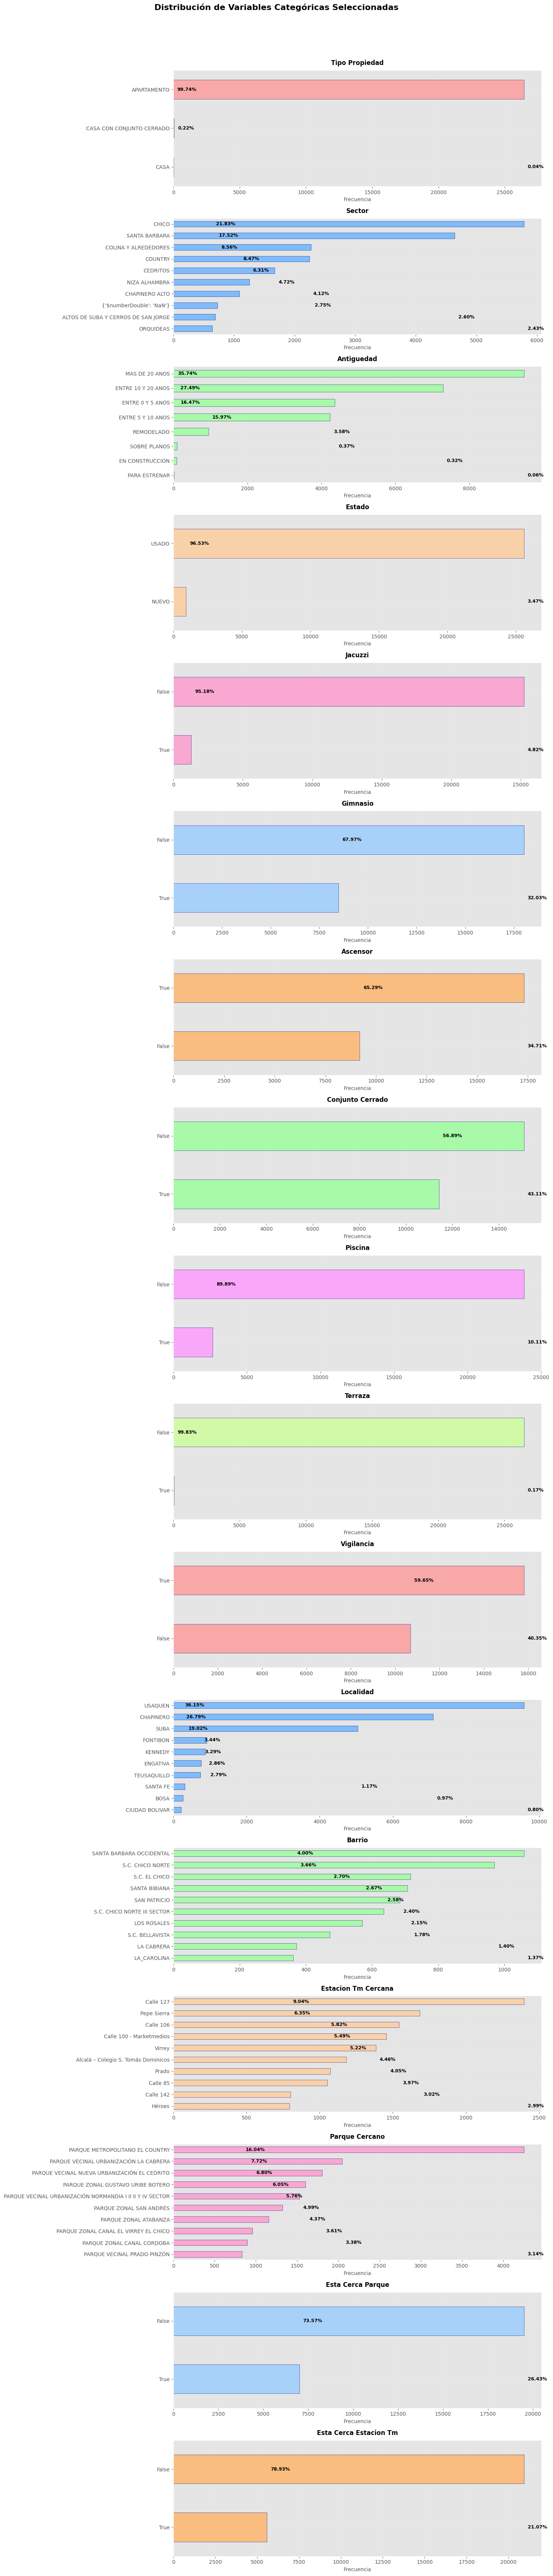

In [ ]:
# Crear gráficas para todas las variables categóricas
# ==============================================================================
# Obtener columnas categóricas de categoricas_selec
columnas_cat = [col for col in categoricas_selec if col in datos.columns]

num_plots = len(columnas_cat)
if num_plots == 0:
    print("No se han seleccionado variables categóricas válidas para graficar.")
else:
    ncols = 1 # Mantener 1 columnas por fila
    nrows = (num_plots + ncols - 1) // ncols # Calcular filas necesarias, redondeando hacia arriba

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flat # Aplanar el array de ejes para facilitar la iteración

    # Colores personalizados (se ciclarán si hay más plots que colores)
    colores = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC',
               '#99CCFF', '#FFB366', '#99FF99', '#FF99FF', '#CCFF99']

    for i, columna in enumerate(columnas_cat):
        # Asegurarse de que la columna existe en datos y tiene suficientes valores
        if datos[columna].count() > 0:
            # Convertir a string antes de contar para manejar tipos complejos como dicts
            temp_col = datos[columna].apply(lambda x: str(x) if isinstance(x, (dict, list)) else x)

            # Calcular frecuencias absolutas y porcentajes para la COLUMNA ACTUAL
            frecuencias = temp_col.value_counts()
            porcentajes = (temp_col.value_counts(normalize=True) * 100).round(2)

            # Para evitar sobrecargar el gráfico, mostramos solo las top 10 categorías si hay muchas
            if len(frecuencias) > 10:
                frecuencias = frecuencias.head(10)
                porcentajes = porcentajes.head(10)

            # Crear gráfica de barras horizontales con frecuencias absolutas
            # Revertir el orden para que la categoría más frecuente esté arriba
            frecuencias.sort_values(ascending=True).plot.barh(
                ax=axes[i],
                color=colores[i % len(colores)],
                edgecolor='navy',
                alpha=0.8
            )

            # Personalizar cada subplot
            axes[i].set_title(columna.replace('_', ' ').title(),
                             fontsize=12,
                             fontweight="bold",
                             pad=10)
            axes[i].tick_params(labelsize=10)
            axes[i].set_xlabel("Frecuencia", fontsize=10)
            axes[i].set_ylabel("") # Eliminar etiqueta predeterminada del eje y

            axes[i].grid(True, linestyle='--', alpha=0.3)

            # Añadir etiquetas de porcentaje
            # Se usa `zip` con los valores de `frecuencias` y `porcentajes` en el orden correcto
            for idx, (freq, pct) in enumerate(zip(frecuencias.values, porcentajes.sort_values(ascending=True).values)):
                axes[i].text(freq + (axes[i].get_xlim()[1] * 0.01), idx, f'{pct:.2f}%',
                            va='center',
                            fontsize=9,
                            fontweight='bold')
        else:
            axes[i].set_visible(False) # Ocultar subplot si no hay datos

    # Eliminar subplots vacíos si los hay
    for j in range(num_plots, nrows * ncols):
        fig.delaxes(axes[j])

    # Ajustar layout
    plt.tight_layout()

    # Añadir título general
    fig.suptitle('Distribución de Variables Categóricas Seleccionadas',
                fontsize=16,
                fontweight="bold",
                y=1.02)

    plt.show()

In [ ]:
# Crear gráficas de torta para todas las variables categóricas
# ==============================================================================
# (excluyendo 'compania' y 'closets' si se determinó que son problemáticas)
# Utiliza la lista 'categoricas_selec' definida en celdas anteriores

columnas_cat_filtradas = [col for col in categoricas_selec if col in datos.columns]

# Determinar el número de filas y columnas para los subplots dinámicamente
num_plots_pie = len(columnas_cat_filtradas)
if num_plots_pie == 0:
    print("No se han seleccionado variables categóricas válidas para graficar.")
else:
    # Se usa 1 columnas por fila, ajustando el número de filas según sea necesario
    ncols_pie = 1
    nrows_pie = (num_plots_pie + ncols_pie - 1) // ncols_pie

    fig, axes = plt.subplots(nrows=nrows_pie, ncols=ncols_pie, figsize=(15, 5 * nrows_pie))
    axes = axes.flat

    # Colores personalizados
    colores_pie = plt.cm.Set3.colors # Usar un colormap predefinido para una buena variedad de colores

    for i, columna in enumerate(columnas_cat_filtradas):
        # Asegurarse de que la columna exista y tenga valores para plotear
        if datos[columna].count() > 0:
            # Convertir a string antes de contar para manejar tipos complejos o mixtos
            temp_col_pie = datos[columna].apply(lambda x: str(x) if isinstance(x, (dict, list)) else x)
            frecuencias_pie = temp_col_pie.value_counts()

            # Solo plotear si hay más de una categoría significativa
            if len(frecuencias_pie) > 1:
                # Limitar a las top 10 categorías para evitar gráficos sobrecargados
                if len(frecuencias_pie) > 10:
                    frecuencias_pie = frecuencias_pie.head(10)

                porcentajes_pie = (frecuencias_pie / frecuencias_pie.sum() * 100).round(2)

                # Crear etiquetas con porcentaje y conteo
                labels_pie = [f'{label} ({pct:.2f}%)' for label, pct in zip(frecuencias_pie.index, porcentajes_pie)]

                # Crear gráfica de torta
                axes[i].pie(porcentajes_pie,
                            labels=labels_pie,
                            autopct='',  # No mostrar porcentajes automáticos, ya están en las etiquetas
                            startangle=90,
                            shadow=True,
                            colors=colores_pie[:len(frecuencias_pie)]) # Usar solo los colores necesarios

                # Personalizar cada subplot
                axes[i].set_title(columna.replace('_', ' ').title(),
                                 fontsize=12,
                                 fontweight="bold",
                                 pad=10)
                axes[i].axis('equal')  # Hacer el gráfico circular
            else:
                # Si solo hay una categoría o ninguna, ocultar el subplot
                axes[i].set_visible(False)
        else:
            axes[i].set_visible(False)

    # Eliminar subplots vacíos si los hay
    for j in range(num_plots_pie, nrows_pie * ncols_pie):
        fig.delaxes(axes[j])

    # Ajustar diseño
    plt.tight_layout()

    # Añadir título general
    fig.suptitle('Distribución de Variables Categóricas',
                fontsize=16,
                fontweight="bold",
                y=1.02)

    plt.show()

##Análisis de Variables Categóricas

## Identificación de Desbalances en Variables

###Desbalances Extremos
Estas variables podrían ser problemáticas al implementar one-hot encoding:

1. **Tipo_propiedad**
- Apartamento: 99.74%
- Casa con conjunto cerrado: 0.22%
- Casa :0.04%
-*Observación*: Extremadamente desbalanceada

2. **Estado**

- Usado: 96.53%
- Nuevo: 3.47%
- *Observación*: Muy desbalanceada

3. **Jacuzzi**

- No: 95.18%
- SI: 4.82%

4. **Terraza**

- NO:99.84%
- SI:0.16%


### Desbalances Moderados
Variables con distribución manejable:

1.**Sector**
- Chico: 21.83%
- Santa Barbara: 17.52%
- Colina y alrededores 8.56%
- Country: 8.47%
- Cedritos: 6.31%
- Niza Alhambra: 4.72%
- Chapinero Alto: 4.12%
- Altos de suba y cerros de San Jorge: 2.60%
- Orquídeas: 2.43%
- Otros...

2. **Antiguedad**

- Mas de 20 años: 35.74%
- Entre 10 y 20 años: 27.49%
- Ente 0 y 5 años:16.47%
- Ente 5 y 10 años: 15.97%
- Remodelado: 3.58%
- Sobre Planos: 0.37%
- En construcción: 0.32%
- Para estrenar: 0.06%


3. **localidad**

- Usaquen: 36.11%
- Chapinero:27.07%
- Suba: 18.51%
- Fontibón: 3.84%
- Kennedy: 3.17%
- Engativa:2.78%
- Teusaquillo:2.68%
- Bosa:1.15%
- Santa fe: 1.13%
- Ciudad Bolivar: 0.77%

4. **Piscina**

- NO: 89.56%
- SI: 10.44%

5. **Esta cerca parque**

- NO: 73.99%
- SI: 26.01%

6. **Esta cerca Estación TM**

- NO:79.56%
- SI:20.44%


### Variables más Balanceadas
Variables con distribución más equilibrada:

1. **Barrio**

- Santa Barbara: 3.88%
- Chico Norte: 3.70%
- El Chico:2.72%
- Santa BIBIANA: 2.58%
- san patricio:2.49%
- Chico Norte III Sector:2.32%
- Los rosales:2.23%
- Bellavista:1.86%
- La cabrera:1.44%
- La carolina: 1.35%

2. **Estación TM Cerca**

- alle 127: 8.84%
- Calle 106: 6.44%
- Pepe Sierra: 6.34%
- Virrey:5.40%
- Calle 10: 5.34%
- Alcala: 4.33%
- Calle 85:4.07%
- Prado:3.93%
- Heroes: 3.06%
- Calle 142:2.91%

3. **Parque Cercano**

- Parque metropolitano: 16.52%
- Parque vecinal Urb La cabrera: 8.06%
- Parque Vecinal Nueva Urb El Cedrito: 6.60%
- Parque Zonal Gustavo Uribe: 6.06%
- Parque Vecinal Urb Normandia: 5.59%
- Parque Zonal San andres: 5.08%
- Parque zonal atabanza:4.25%
- Parque zonal canal: 3.64%
- Parque Zonal Canal Cordoba: 3.26%
- Parqeu Vecinal Prado Pinzon: 3.02%

4. **ASCENSOR**

- SI:65.29%
- NO:34.71%

5. **Gimnasio**

- NO: 67.97%
- SI: 32.03%

7. **Conjunto Cerrado**

- NO: 56.89%
- SI: 43.11%


8. **Vigilancia**

- SI: 59.70%
- NO: 40.30%

### Recomendaciones

1. **Para Variables Extremadamente Desbalanceadas**
  - Considerar eliminación
  - Aplicar técnicas de balanceo
  - Evaluar combinación con otras variables

2. **Para Variables Multiclase**
  - Mantener variables con distribución informativa
  - Evaluar agrupación de categorías menos frecuentes

3. **Consideraciones para One-Hot Encoding**
  - Evaluar impacto en dimensionalidad
  - Considerar técnicas alternativas de encoding
  - Monitorear efectos en el rendimiento del modelo

## Conclusión
El análisis sugiere la necesidad de un tratamiento especial para variables categóricas antes de su inclusión en el modelo, especialmente aquellas con desbalances extremos.

In [ ]:
cols_amenidades = ['jacuzzi', 'chimenea', 'permite_mascotas', 'gimnasio',
                   'ascensor', 'conjunto_cerrado', 'piscina', 'salon_comunal',
                   'terraza', 'vigilancia']

print("Tipos de datos actuales para las variables de amenidades:")
for col in cols_amenidades:
    if col in datos.columns:
        print(f"- {col}: {datos[col].dtype}")
    else:
        print(f"- {col}: No se encontró en el DataFrame.")


Tipos de datos actuales para las variables de amenidades:
- jacuzzi: bool
- chimenea: bool
- permite_mascotas: bool
- gimnasio: bool
- ascensor: bool
- conjunto_cerrado: bool
- piscina: bool
- salon_comunal: bool
- terraza: bool
- vigilancia: bool


#Selección de Variables Categóricas para el Modelo

## **Variables Recomendadas para Incluir**
Variables con Distribución Balanceada y moderadas
- Dejamos una variable de ubicación
Sector, Localidad, Barrio
- Antigüedad,Gimnasio,Piscina,Ascensor,Vigilancia,Conjunto Cerrado
- Esta Cerca Parque,Esta Cerca Estación TM,Esta TM Cerca,Parque Cercano


1. **Localidad**

Razón: Distribución aceptable entre las categorías principales
Relevancia: Factor importante en el valor de una propiedad cerca a lo comercial o residencial
Tratamiento: Puede usarse directamente con one-hot encoding

2. **Antiguedad**

Razón: Distribución relativamente aceptable entre las categorías principales
Relevancia: Infraestructura crítica que afecta el valor
Tratamiento: Eliminar o reclasificar la categoría 'NaN' (0.04%)

3. **Vigilancia**

Razón: Distribución relativamente balanceada (59.70% vs 40.30%)
Relevancia: Seguridad
Tratamiento: Usar directamente

4. **Gimnasio**

Razón: Distribución relativamente balanceada (67.77% vs 32.23%)
Relevancia: Comodidas exclusivas
Tratamiento: Usar directamente

5. **Ascensor**

Razón: Distribución relativamente balanceada (65.05% vs 34.95%)
Relevancia: Sistema esencial en la vivienda
Tratamiento: Usar directamente

6. **Esta Cerca Estación TM**

Razón: Distribución balenceada-moderado (79.56% vs 20.44%)
Relevancia: Impacto en la facilidad de movilidad
Tratamiento: Usar directamente

**Justificación**
Las variables seleccionadas tienen suficiente variabilidad para ser informativas
Evitamos variables que podrían introducir ruido por desbalance extremo
Mantenemos variables que lógicamente influyen en el precio de un apartamento

In [ ]:
# Crear un DataFrame con solo las variables cualitativas/categóricas
datos_cuali = datos.select_dtypes(include=['object', 'category', 'boolean'])

# Crear el nuevo DataFrame con las variables seleccionadas
datos_selec_cat_modelo = datos_cuali [['localidad', 'antiguedad', 'vigilancia',
                                   'gimnasio', 'ascensor', 'esta_cerca_estacion_tm']]
print("DataFrame de variables categóricas seleccionadas para el modelo (datos_selec_cat_modelo) creado:")
display(datos_selec_cat_modelo.head())

DataFrame de variables categóricas seleccionadas para el modelo (datos_selec_cat_modelo) creado:


,localidad,antiguedad,vigilancia,gimnasio,ascensor,esta_cerca_estacion_tm
0,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
1,USAQUEN,MAS DE 20 ANOS,False,False,False,False
2,LOS MARTIRES,ENTRE 0 Y 5 ANOS,False,False,False,True
3,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
4,USAQUEN,MAS DE 20 ANOS,False,False,False,False


#MODELO

In [ ]:
# Combinar los DataFrames
modelo = pd.concat([datos_selec_num_modelo, datos_selec_cat_modelo], axis=1)
modelo.head()

,precio_boxcox,parqueaderos,banyos,estrato,habitaciones,area,distancia_parque_m,localidad,antiguedad,vigilancia,gimnasio,ascensor,esta_cerca_estacion_tm
0,122.05,1,2.00,3,3.00,76.00,426.09,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
1,114.16,0,2.00,3,3.00,63.00,472.47,USAQUEN,MAS DE 20 ANOS,False,False,False,False
2,127.26,0,2.00,3,3.00,54.00,961.29,LOS MARTIRES,ENTRE 0 Y 5 ANOS,False,False,False,True
3,108.04,0,2.00,2,2.00,43.00,539.98,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
4,114.15,0,2.00,3,3.00,48.00,"1,661.14",USAQUEN,MAS DE 20 ANOS,False,False,False,False


In [ ]:
print(f"Total number of records in the DataFrame: {len(modelo)}")

Total number of records in the DataFrame: 26506


#Transformaciones

##Valores Nulos:

Identificación de valores Nulos, alcer solo un dato en variables como parqueadero,baños, estrato y habitación se procede a eliminarlo.

In [ ]:
# Número de datos ausentes por variable
# ==============================================================================
modelo.isna().sum().sort_values()

,0
precio_boxcox,0
parqueaderos,0
banyos,0
estrato,0
habitaciones,0
area,0
distancia_parque_m,0
localidad,0
antiguedad,0
vigilancia,0


In [ ]:
# Columnas a revisar y eliminar nulos
columnas_con_nulos_a_eliminar = ['parqueaderos', 'banyos', 'estrato', 'habitaciones']

# Eliminar filas donde cualquiera de las columnas especificadas tiene un valor nulo
modelo.dropna(subset=columnas_con_nulos_a_eliminar, inplace=True)

print("Valores nulos después de eliminar los registros en las columnas especificadas:")
print(modelo.isna().sum().sort_values())

Valores nulos después de eliminar los registros en las columnas especificadas:
precio_boxcox             0
parqueaderos              0
banyos                    0
estrato                   0
habitaciones              0
area                      0
distancia_parque_m        0
localidad                 0
antiguedad                0
vigilancia                0
gimnasio                  0
ascensor                  0
esta_cerca_estacion_tm    0
dtype: int64


In [ ]:

print(f"Total number of records in the DataFrame: {len(modelo)}")

Total number of records in the DataFrame: 26506


In [ ]:
print("Valores únicos para las variables seleccionadas en datos_selec_cat_modelo:")

for col in datos_selec_cat_modelo.columns:
    print(f"\n--- Columna: {col} ({datos_selec_cat_modelo[col].dtype}) ---")
    unique_values = datos_selec_cat_modelo[col].unique()
    num_unique = len(unique_values)
    if num_unique > 20:
        print(f"Total de valores únicos: {num_unique}")
        print("Primeros 20 valores únicos:")
        for i, val in enumerate(unique_values[:20]):
            print(f"  - {val}")
    else:
        print(f"Total de valores únicos: {num_unique}")
        for val in unique_values:
            print(f"  - {val}")


Valores únicos para las variables seleccionadas en datos_selec_cat_modelo:

--- Columna: localidad (category) ---
Total de valores únicos: 19
  - SUBA
  - USAQUEN
  - LOS MARTIRES
  - BOSA
  - PUENTE ARANDA
  - ENGATIVA
  - TEUSAQUILLO
  - CHAPINERO
  - KENNEDY
  - SANTA FE
  - BARRIOS UNIDOS
  - RAFAEL URIBE URIBE
  - FONTIBON
  - SAN CRISTOBAL
  - CIUDAD BOLIVAR
  - USME
  - TUNJUELITO
  - ANTONIO NARINO
  - CANDELARIA

--- Columna: antiguedad (category) ---
Total de valores únicos: 8
  - ENTRE 10 Y 20 ANOS
  - MAS DE 20 ANOS
  - ENTRE 0 Y 5 ANOS
  - ENTRE 5 Y 10 ANOS
  - REMODELADO
  - PARA ESTRENAR
  - SOBRE PLANOS
  - EN CONSTRUCCION

--- Columna: vigilancia (bool) ---
Total de valores únicos: 2
  - False
  - True

--- Columna: gimnasio (bool) ---
Total de valores únicos: 2
  - False
  - True

--- Columna: ascensor (bool) ---
Total de valores únicos: 2
  - False
  - True

--- Columna: esta_cerca_estacion_tm (bool) ---
Total de valores únicos: 2
  - False
  - True


Todas las variables categoricas VS Precio

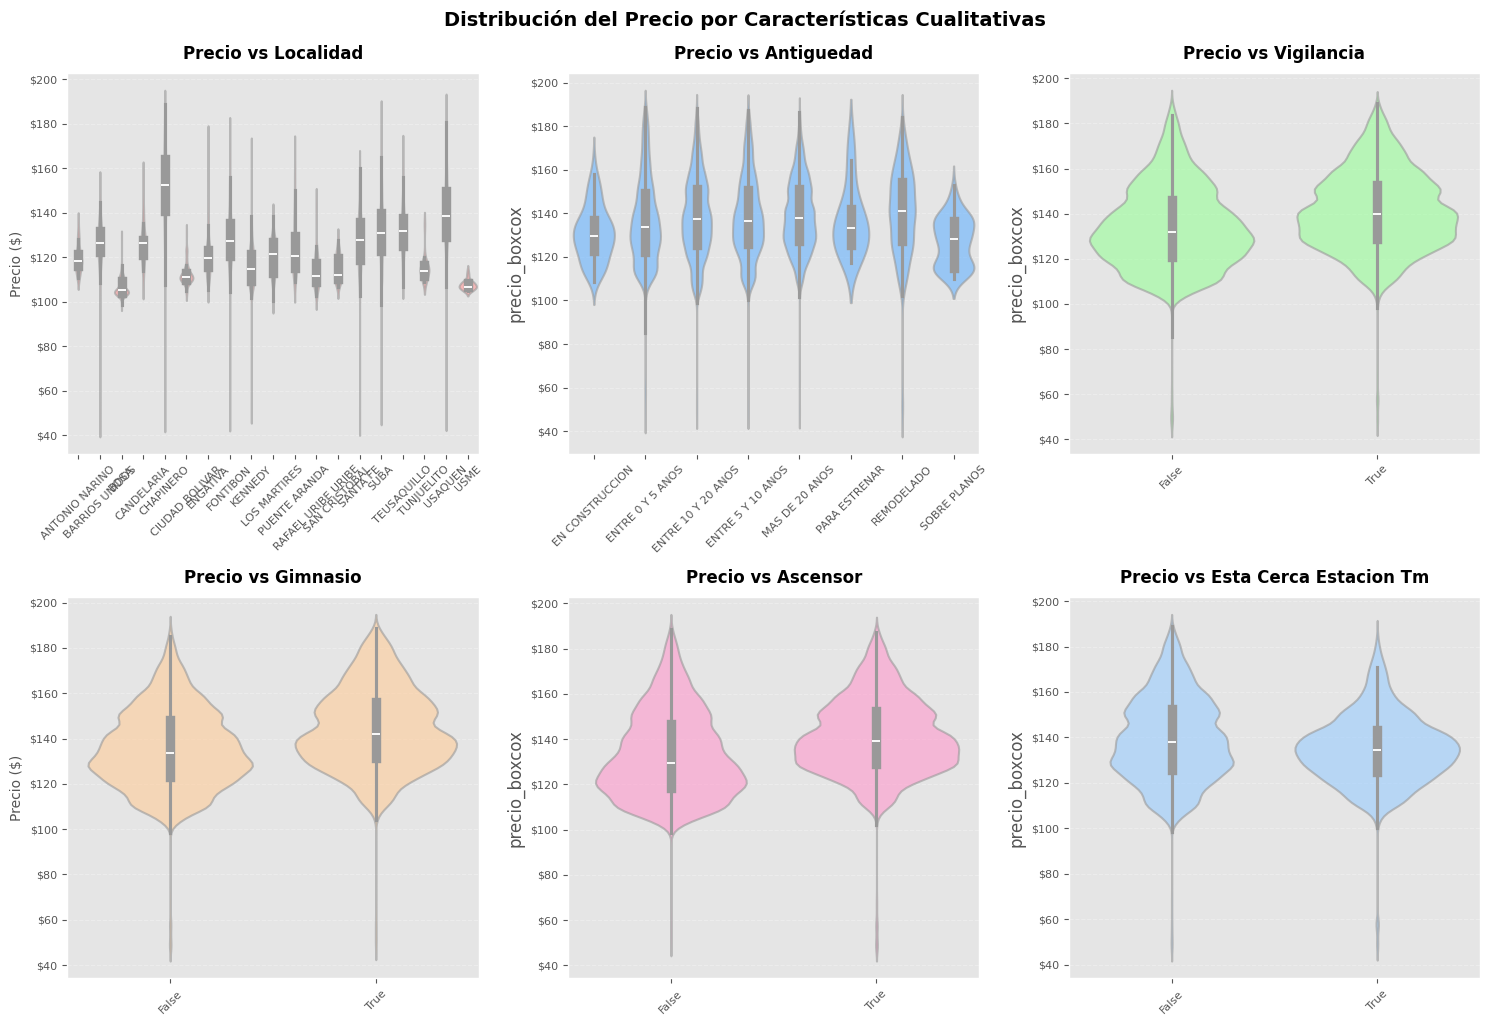

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Seleccionar variables categóricas
columnas_object = ['localidad', 'antiguedad', 'vigilancia',
                                   'gimnasio', 'ascensor', 'esta_cerca_estacion_tm']

# Crear subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flat

# Paleta de colores personalizada
colores = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#99CCFF']

# Crear los violin plots
for i, columna in enumerate(columnas_object):
   # Crear violin plot
   sns.violinplot(
       x=columna,
       y='precio_boxcox',
       data=modelo,
       ax=axes[i],
       color='white',
       inner='box',
       linewidth=1.5,
       saturation=0.7
   )

   # Personalizar cada subplot
   axes[i].set_title(f'Precio vs {columna.replace("_", " ").title()}',
                    fontsize=12,
                    fontweight='bold',
                    pad=10)

   # Formatear eje Y para mostrar precios en miles
   axes[i].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'${x:,.0f}'))

   # Rotar etiquetas del eje X
   axes[i].tick_params(axis='x', rotation=45, labelsize=8)
   axes[i].tick_params(axis='y', labelsize=8)

   # Añadir grid suave solo en el eje Y
   axes[i].yaxis.grid(True, linestyle='--', alpha=0.3)
   axes[i].set_axisbelow(True)

   # Personalizar colores
   violins = axes[i].collections
   for violin in violins:
       violin.set_facecolor(colores[i])
       violin.set_alpha(0.6)

   # Etiquetas
   axes[i].set_xlabel('')
   if i % 3 == 0:
       axes[i].set_ylabel('Precio ($)', fontsize=10)

# Ajustar layout
plt.tight_layout()

# Título general
fig.suptitle('Distribución del Precio por Características Cualitativas',
            fontsize=14,
            fontweight='bold',
            y=1.02)

# Mostrar el gráfico
plt.show()

#Entrenamiento y testeo

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

num_cols = ['parqueaderos','banyos','estrato','habitaciones','area','distancia_parque_m']
cat_cols = ['localidad','antiguedad','vigilancia','gimnasio','ascensor','esta_cerca_estacion_tm']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    modelo.drop('precio_boxcox', axis='columns'),
    modelo['precio_boxcox'],
    train_size=0.8,
    random_state=1998,
    shuffle=True
)


In [ ]:
modelo

,precio_boxcox,parqueaderos,banyos,estrato,habitaciones,area,distancia_parque_m,localidad,antiguedad,vigilancia,gimnasio,ascensor,esta_cerca_estacion_tm
0,122.05,1,2.00,3,3.00,76.00,426.09,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
1,114.16,0,2.00,3,3.00,63.00,472.47,USAQUEN,MAS DE 20 ANOS,False,False,False,False
2,127.26,0,2.00,3,3.00,54.00,961.29,LOS MARTIRES,ENTRE 0 Y 5 ANOS,False,False,False,True
3,108.04,0,2.00,2,2.00,43.00,539.98,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
4,114.15,0,2.00,3,3.00,48.00,"1,661.14",USAQUEN,MAS DE 20 ANOS,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
43008,111.27,0,2.00,2,3.00,49.00,198.03,SUBA,ENTRE 10 Y 20 ANOS,False,True,False,False
43009,121.05,1,2.00,4,3.00,66.00,631.25,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,True
43010,121.53,0,2.00,4,3.00,90.00,"1,211.62",TEUSAQUILLO,MAS DE 20 ANOS,False,False,False,True
43011,150.65,3,3.00,6,3.00,157.00,"1,269.56",USAQUEN,MAS DE 20 ANOS,False,False,True,False


In [ ]:
modelo.shape

(26506, 13)

In [ ]:
# Reparto de datos en train y test
# ==============================================================================
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
                                        modelo.drop('precio_boxcox', axis = 'columns'),
                                        modelo['precio_boxcox'],
                                        train_size   = 0.8,
                                        random_state = 1998,
                                        shuffle      = True
                                    )

In [ ]:
X_train

,parqueaderos,banyos,estrato,habitaciones,area,distancia_parque_m,localidad,antiguedad,vigilancia,gimnasio,ascensor,esta_cerca_estacion_tm
27772,2,5.00,6,3.00,165.00,367.49,USAQUEN,REMODELADO,False,False,True,False
28754,1,2.00,3,3.00,67.00,427.47,ENGATIVA,ENTRE 10 Y 20 ANOS,False,False,False,False
23237,0,1.00,3,3.00,57.00,608.45,ENGATIVA,MAS DE 20 ANOS,False,False,False,False
4190,0,1.00,3,1.00,23.00,"1,354.54",TEUSAQUILLO,ENTRE 5 Y 10 ANOS,True,False,True,True
26279,2,2.00,5,2.00,80.00,939.80,USAQUEN,MAS DE 20 ANOS,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...
8226,0,2.00,2,3.00,56.00,232.96,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
39981,3,5.00,6,4.00,325.00,858.13,CHAPINERO,REMODELADO,True,False,True,False
9500,1,2.00,4,3.00,53.67,334.93,USAQUEN,ENTRE 10 Y 20 ANOS,False,False,True,False
7142,1,2.00,4,3.00,113.00,432.91,TEUSAQUILLO,MAS DE 20 ANOS,True,False,False,False


In [ ]:
X_test

,parqueaderos,banyos,estrato,habitaciones,area,distancia_parque_m,localidad,antiguedad,vigilancia,gimnasio,ascensor,esta_cerca_estacion_tm
9383,1,2.00,4,2.00,57.00,51.31,SUBA,MAS DE 20 ANOS,True,False,True,False
22892,2,4.00,6,3.00,225.00,488.72,USAQUEN,MAS DE 20 ANOS,True,False,True,False
42493,0,2.00,4,2.00,46.00,969.71,FONTIBON,ENTRE 0 Y 5 ANOS,False,True,True,False
30878,2,2.00,4,3.00,105.00,639.23,SUBA,ENTRE 10 Y 20 ANOS,False,True,True,False
27354,3,5.00,6,4.00,226.00,906.13,USAQUEN,MAS DE 20 ANOS,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
30992,0,1.00,3,2.00,41.06,"1,012.19",SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
36991,2,3.00,5,3.00,140.00,"1,134.14",USAQUEN,MAS DE 20 ANOS,False,False,True,True
39842,0,2.00,3,3.00,147.00,"1,115.64",CHAPINERO,MAS DE 20 ANOS,True,False,True,True
35204,0,1.00,2,2.00,36.00,653.06,SUBA,ENTRE 5 Y 10 ANOS,True,True,False,False


In [ ]:
y_train

,precio_boxcox
27772,139.87
28754,120.14
23237,109.82
4190,110.32
26279,131.43
...,...
8226,108.79
39981,177.24
9500,122.67
7142,131.81


In [ ]:
y_test

,precio_boxcox
9383,118.39
22892,150.09
42493,120.57
30878,133.64
27354,148.13
...,...
30992,106.44
36991,136.95
39842,135.02
35204,107.70


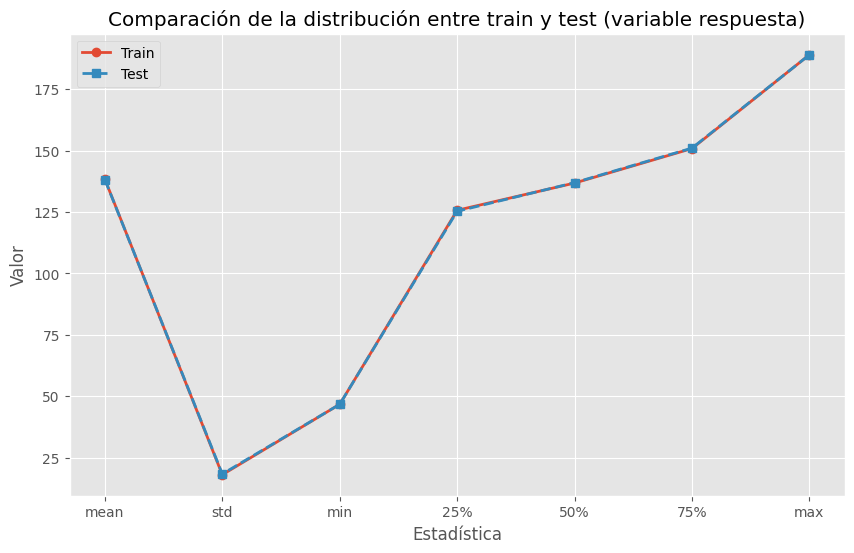

In [ ]:
import matplotlib.pyplot as plt

# Calcular estadísticas descriptivas
y_train_stats = y_train.describe()
y_test_stats = y_test.describe()

# Extraer las estadísticas clave para la gráfica
categories = ['mean', 'std', 'min', '25%', '50%', '75%', 'max']
y_train_values = [y_train_stats[stat] for stat in categories]
y_test_values = [y_test_stats[stat] for stat in categories]

# Crear una gráfica comparativa
plt.figure(figsize=(10, 6))
plt.plot(categories, y_train_values, marker='o', label='Train', linestyle='-', linewidth=2)
plt.plot(categories, y_test_values, marker='s', label='Test', linestyle='--', linewidth=2)

# Configurar detalles de la gráfica
plt.title('Comparación de la distribución entre train y test (variable respuesta)')
plt.xlabel('Estadística')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.show()

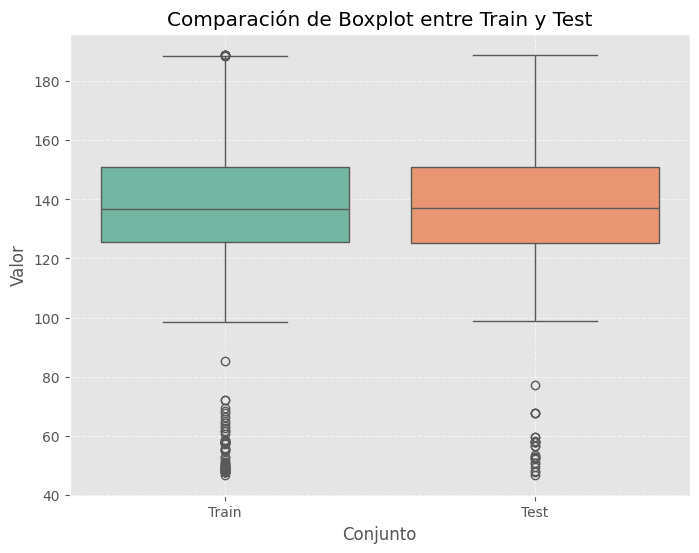

In [ ]:
import seaborn as sns
import pandas as pd

# Combinar los datos en un DataFrame para Seaborn
df_viz = pd.DataFrame({
    'Valor': y_train.tolist() + y_test.tolist(),
    'Conjunto': ['Train'] * len(y_train) + ['Test'] * len(y_test)
})

# Crear el boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Conjunto', y='Valor', data=df_viz, palette='Set2')

# Configurar detalles de la gráfica
plt.title('Comparación de Boxplot entre Train y Test')
plt.ylabel('Valor')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#Conclusión

El divisor train y test fue correcta y balanceada: ambos conjuntos reflejan la misma distribución de la variable objetivo. Crucial porque asegura que el modelo entrenado en train podrá generalizar bien en test, sin riesgo de que el conjunto de prueba tenga un comportamiento distinto.No habría fuga de información ni sesgo en la partición, lo que fortalece la validez del modelo de regresión.


#Exportar el dataset final

In [ ]:
import os

# Define la carpeta donde quieres guardar el archivo
# Cambia esta ruta por la carpeta que necesites
carpeta_salida = r"/content/drive/MyDrive/TALLER_EDA_output"

# Crea la carpeta si no existe
os.makedirs(carpeta_salida, exist_ok=True)

# Exportar a Excel
ruta_salida = os.path.join(carpeta_salida, "apartamentos_bogota_venta_preprocesado.xlsx")
modelo.to_excel(ruta_salida, index=False, sheet_name="datos_preprocesados")

print("Archivo exportado:", ruta_salida)
print("Shape final:", modelo.shape)
display(modelo.head())

Archivo exportado: /content/drive/MyDrive/TALLER_EDA_output/apartamentos_bogota_venta_preprocesado.xlsx
Shape final: (26506, 13)


,precio_boxcox,parqueaderos,banyos,estrato,habitaciones,area,distancia_parque_m,localidad,antiguedad,vigilancia,gimnasio,ascensor,esta_cerca_estacion_tm
0,122.05,1,2.00,3,3.00,76.00,426.09,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
1,114.16,0,2.00,3,3.00,63.00,472.47,USAQUEN,MAS DE 20 ANOS,False,False,False,False
2,127.26,0,2.00,3,3.00,54.00,961.29,LOS MARTIRES,ENTRE 0 Y 5 ANOS,False,False,False,True
3,108.04,0,2.00,2,2.00,43.00,539.98,SUBA,ENTRE 10 Y 20 ANOS,False,False,False,False
4,114.15,0,2.00,3,3.00,48.00,"1,661.14",USAQUEN,MAS DE 20 ANOS,False,False,False,False
